In [134]:
import pandas as pd

In [135]:
df = pd.read_excel("Online Retail.xlsx")

In [136]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [137]:
df.shape

(541909, 8)

#### **Dataset Information**

In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


#### **Statistical Summary of Numerical Features**

In [139]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,541909.0,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303


#### **Data Types Check**

In [140]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

#### **Missing Values Check**

In [141]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

######

#### **Remove Unnecessary Column**

In [142]:
df = df.drop('Description', axis=1)

###### **Reason:** Description is a text-based feature with missing values, and it is not required for customer behavioral clustering. Since StockCode does not have a unique mapping with Description, filling the missing values would not be reliable.

#### **Remove Missing Customer IDs**

In [143]:
df = df.dropna(subset=['CustomerID'])

###### **Reason:** CustomerID is required to identify individual customers and create customer-level behavioral features. Since missing CustomerIDs cannot be reliably assigned to a specific customer, those transaction records are removed.

######

#### **Verify Missing Values After Cleaning**

In [144]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

#### **Duplicate Records Check**

In [145]:
df.duplicated().sum()

np.int64(5227)

#### **Remove Duplicate Records**

In [146]:
df = df.drop_duplicates()

#### **Verify Duplicate Records After Cleaning**

In [147]:
df.duplicated().sum()

np.int64(0)

##

## **Univariate Analysis**

#### **Distribution Analysis of Numerical Features**

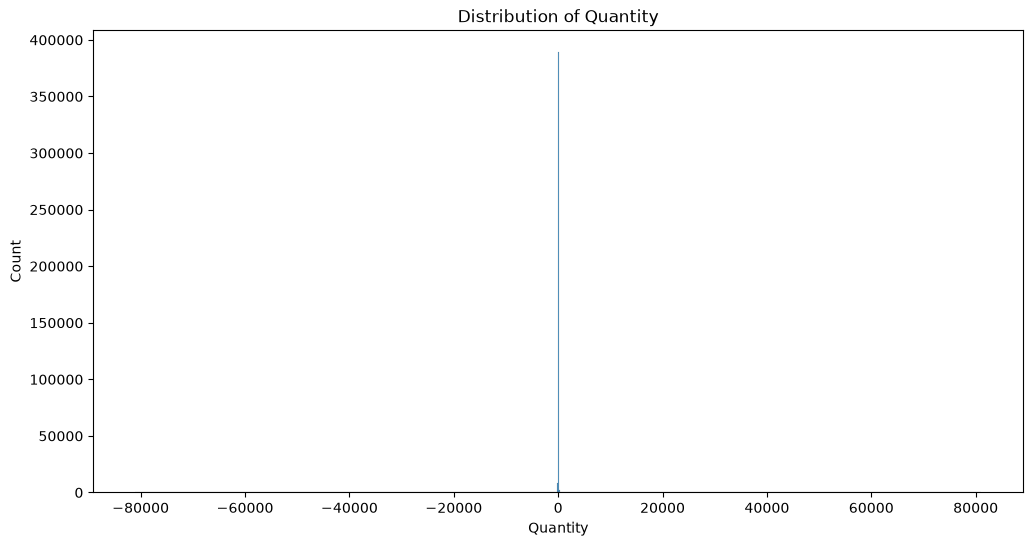

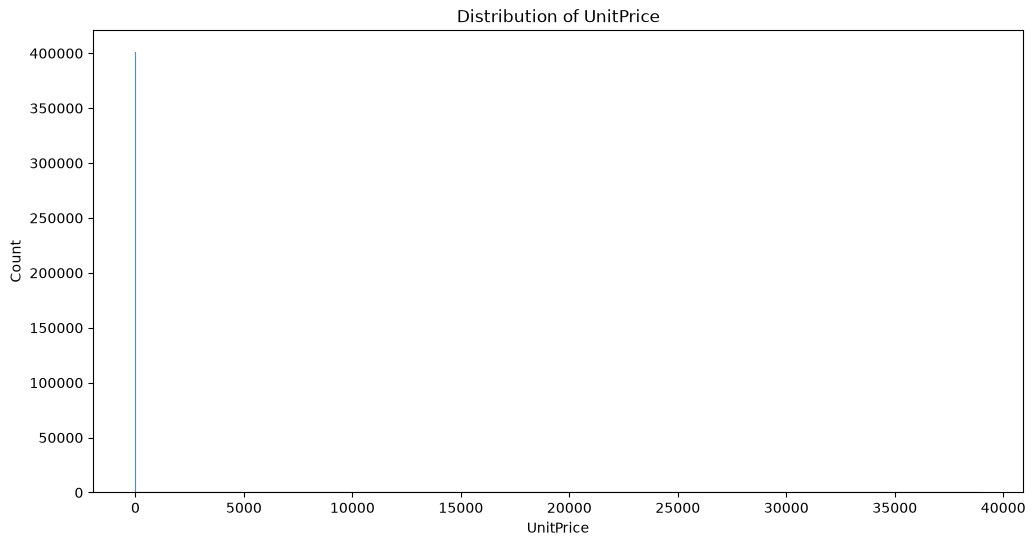

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ["Quantity", "UnitPrice"]

for col in num_cols:
    plt.figure(figsize=(12, 6))
    sns.histplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.show()

######

#### **Box Plot Analysis of Numerical Features**

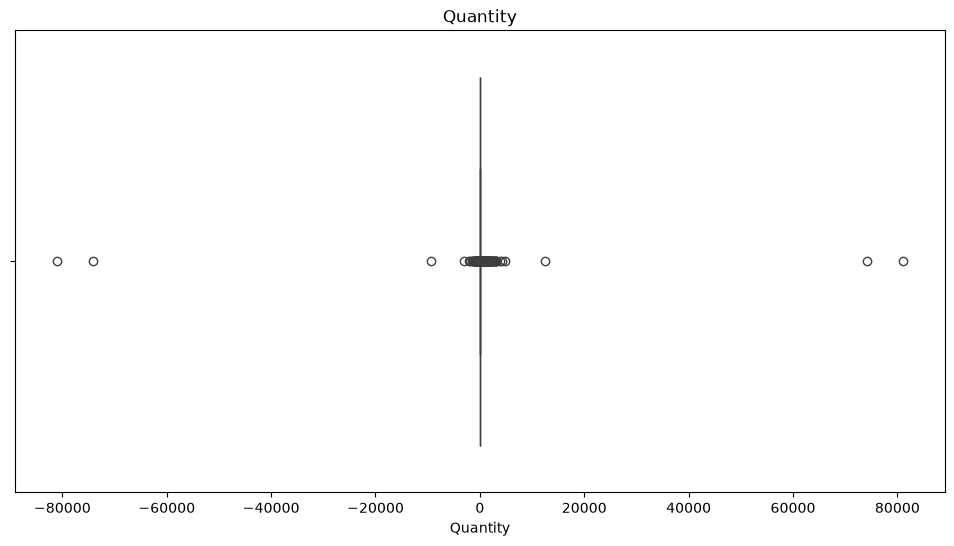

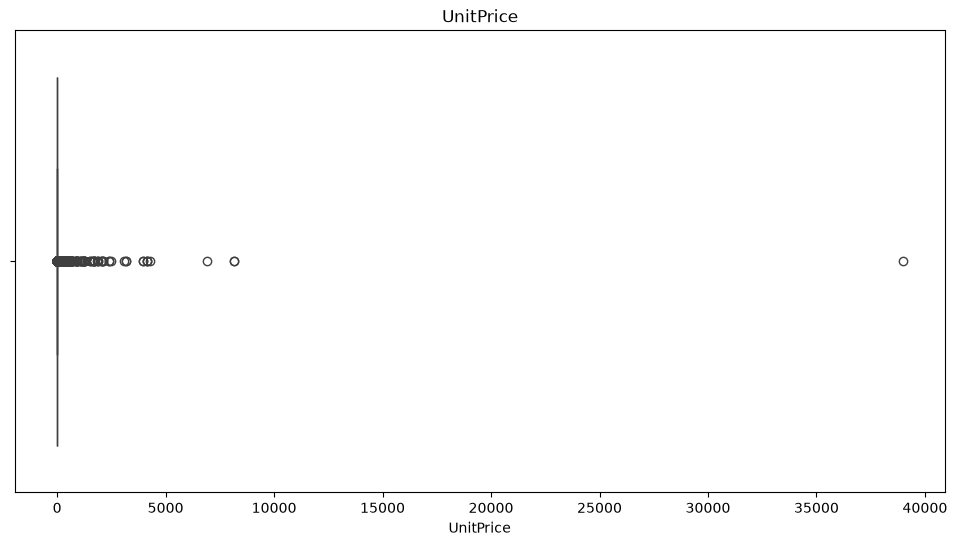

In [149]:
num_cols = ["Quantity", "UnitPrice"]

for col in num_cols:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x=col)
    plt.title(col)
    plt.show()

####

#### **Country Distribution Analysis**

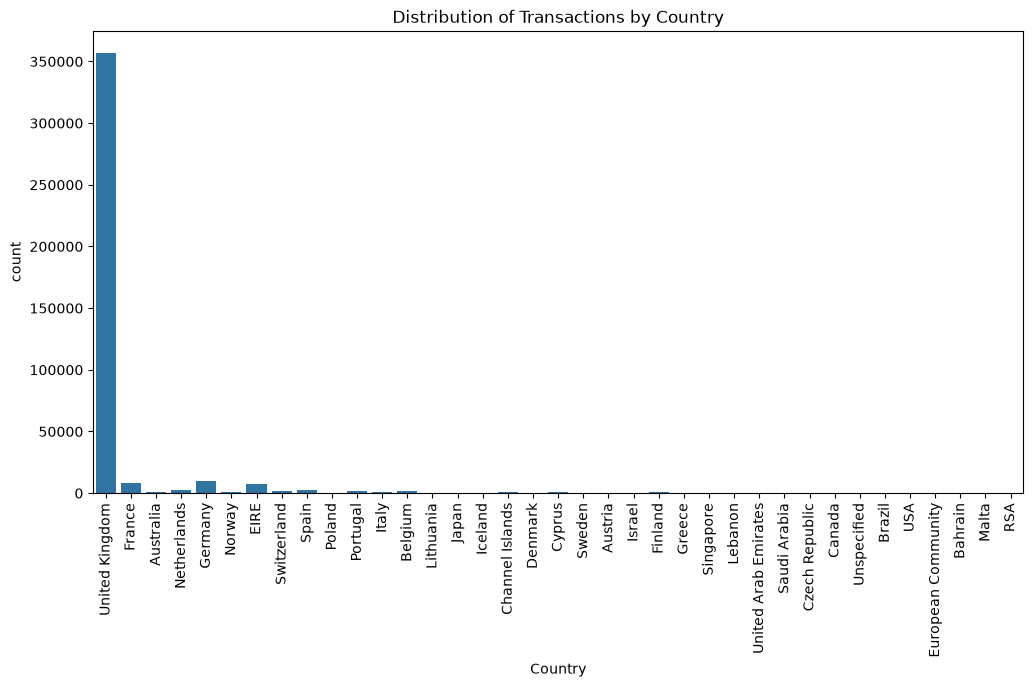

In [150]:
plt.figure(figsize=(12, 6))

sns.countplot(data=df, x='Country')
plt.title('Distribution of Transactions by Country')
plt.xticks(rotation=90)
plt.show()

###

## **Bivariate Analysis**

#### **Correlation Analysis of Numerical Features**

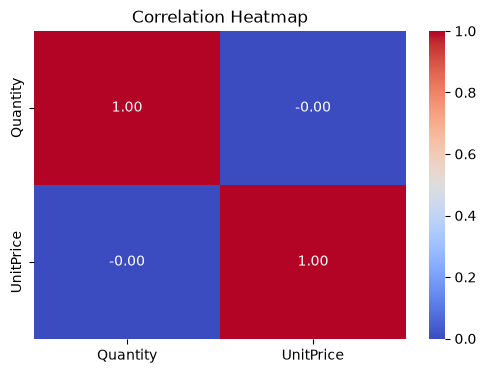

In [151]:
corr_matrix = df[['Quantity', 'UnitPrice']].corr()

plt.figure(figsize=(6, 4))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

######

#### **Scatter Plot Analysis of Quantity and UnitPrice**

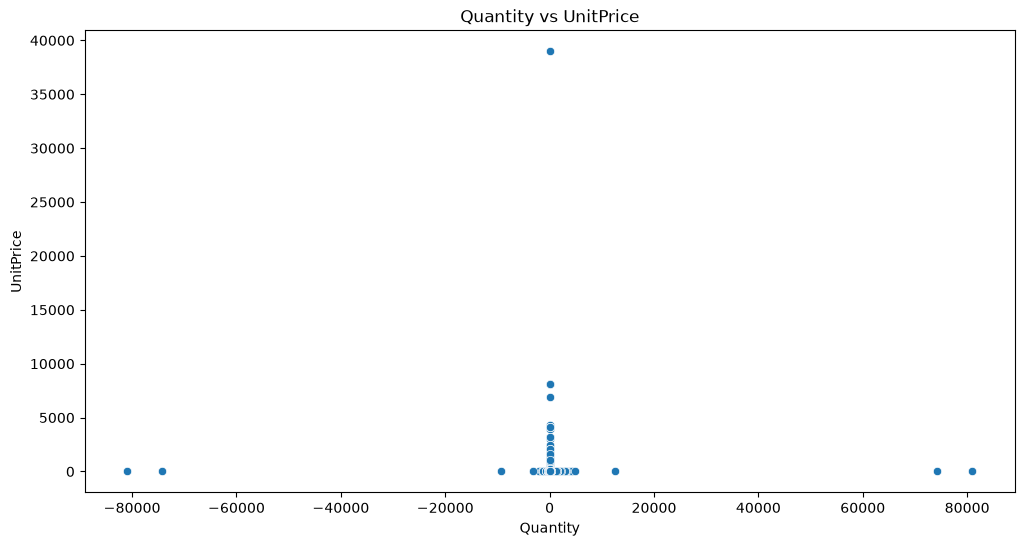

In [152]:
pairs = [
    ('Quantity', 'UnitPrice')
]

for x, y in pairs:
    plt.figure(figsize=(12, 6))
    sns.scatterplot(data=df, x=x, y=y)
    plt.title(f"{x} vs {y}")
    plt.show()

#####

#### **Country Wise Quantity and UnitPrice Analysis**

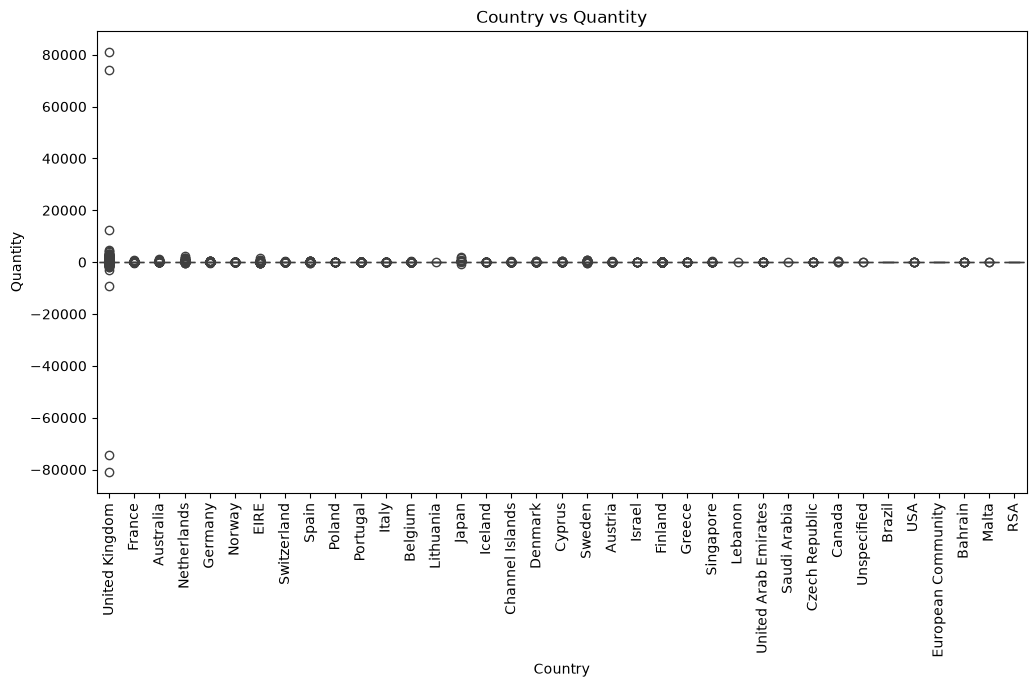

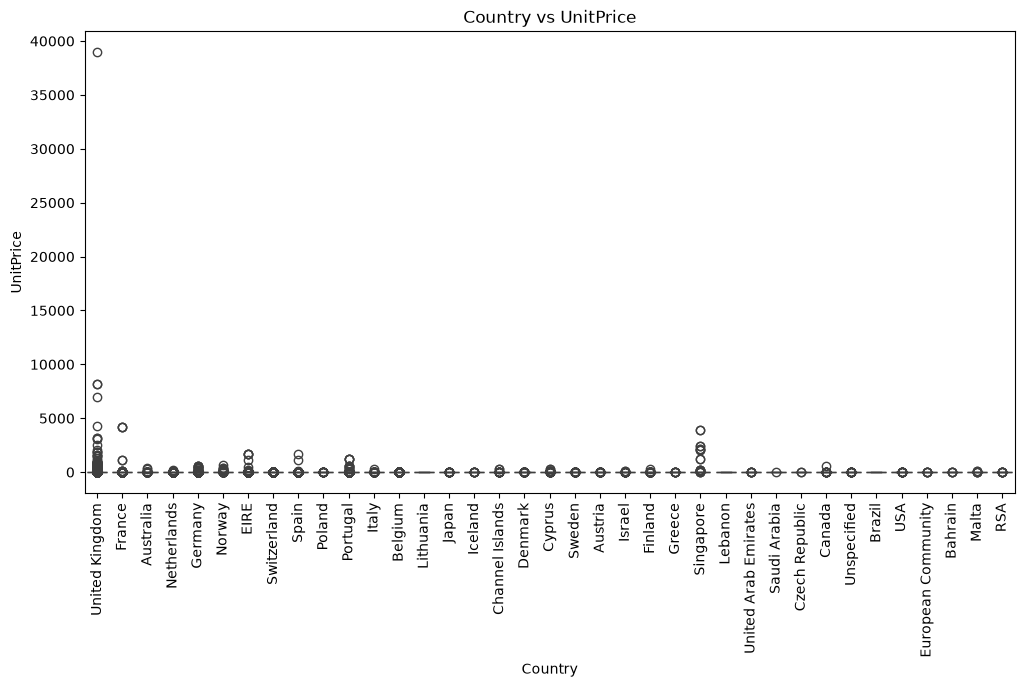

In [153]:
pairs = [
    ('Country', 'Quantity'),
    ('Country', 'UnitPrice')
]

for x, y in pairs:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x=x, y=y)
    plt.title(f"{x} vs {y}")
    plt.xticks(rotation=90)
    plt.show()

###

#### **Convert InvoiceDate to Datetime Format**

In [154]:
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate'],
    format="%Y-%m-%d %H:%M:%S"
)

#### **Verify InvoiceDate Datatype**

In [155]:
df.dtypes

InvoiceNo              object
StockCode              object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

#####

#### **Monthly Transaction Trend Analysis**

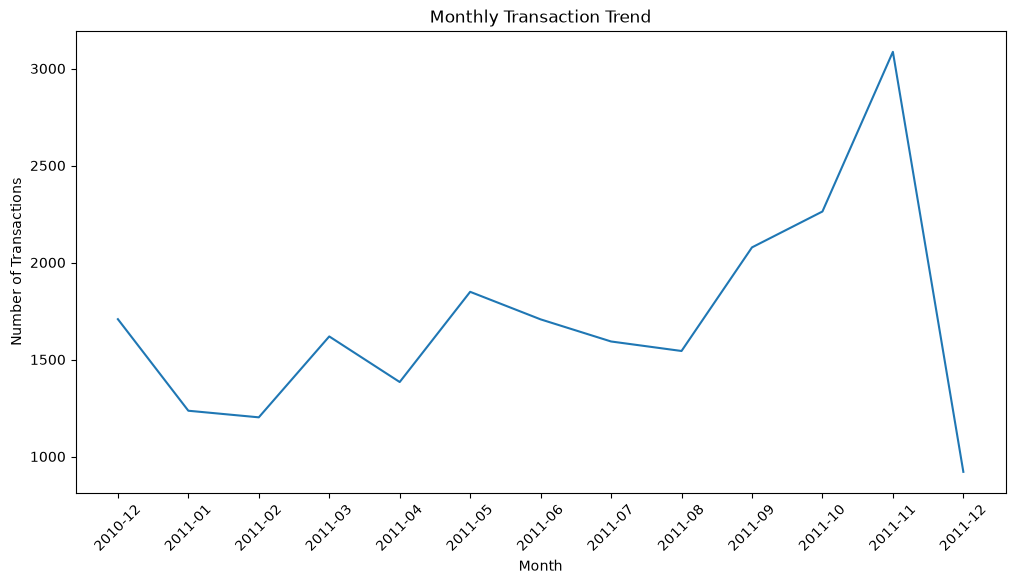

In [156]:
monthly_transactions = df.groupby(
    df['InvoiceDate'].dt.to_period('M')
)['InvoiceNo'].nunique()

plt.figure(figsize=(12, 6))
plt.plot(monthly_transactions.index.astype(str), monthly_transactions.values)

plt.title('Monthly Transaction Trend')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')

plt.xticks(rotation=45)
plt.show()

######

#### **Daily Transaction Trend Analysis**

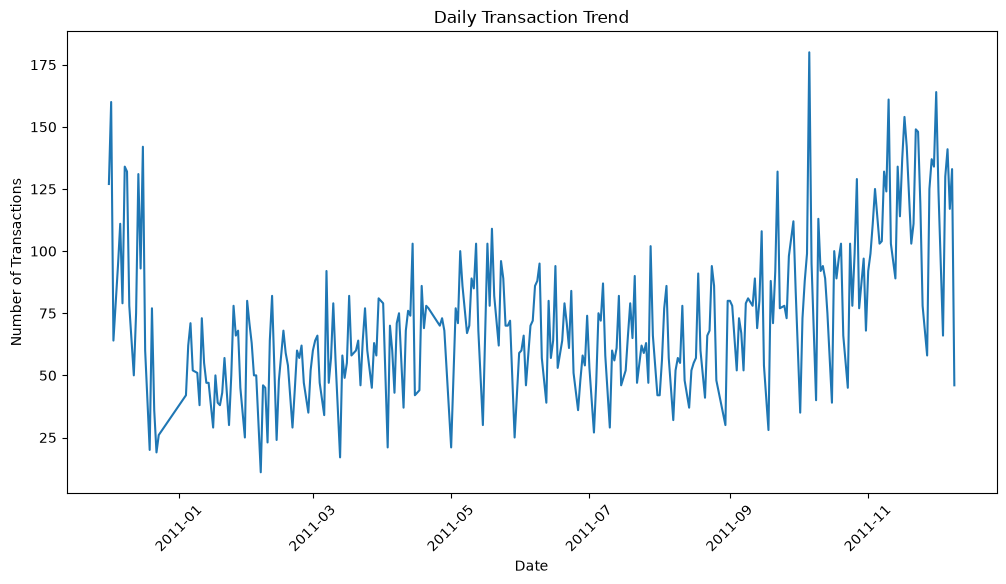

In [157]:
daily_transactions = df.groupby(
    df['InvoiceDate'].dt.date
)['InvoiceNo'].nunique()

plt.figure(figsize=(12, 6))
plt.plot(daily_transactions.index, daily_transactions.values)

plt.title('Daily Transaction Trend')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')

plt.xticks(rotation=45)
plt.show()

###

#### **Outlier Detection in Numerical Features**

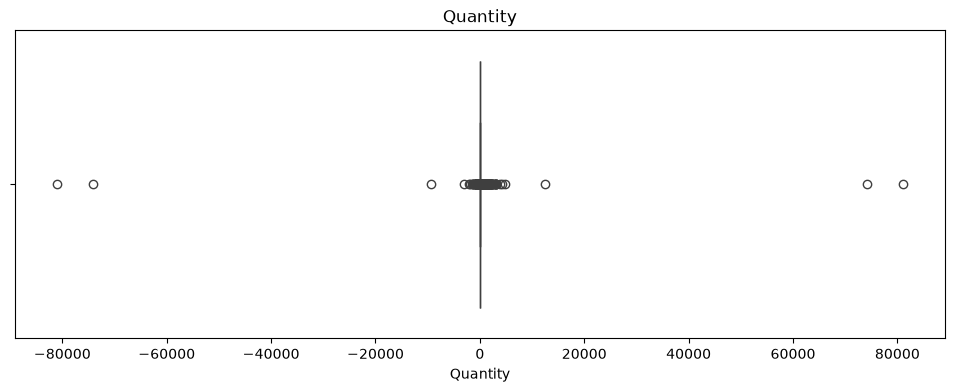

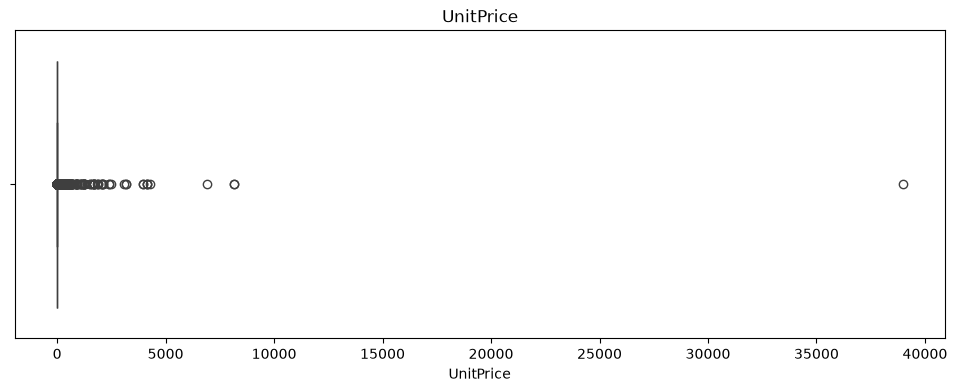

In [158]:
cols = ['Quantity', 'UnitPrice']

for col in cols:
    plt.figure(figsize=(12, 4))
    sns.boxplot(data=df, x=col)
    plt.title(col)
    plt.show()

#### **Filtering Valid Transactions**

In [159]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

####

#### **Create Revenue Feature**

In [160]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

#### **RFM-Based Customer Feature Engineering**

In [161]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

#### Recency Feature Creation

In [162]:
recency = df.groupby('CustomerID')['InvoiceDate'].max().reset_index()

recency['Recency'] = (
    reference_date - recency['InvoiceDate']
).dt.days

#### **Frequency Feature Creation**

In [163]:
frequency = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()

frequency.columns = ['CustomerID', 'Frequency']

#### **Monetary Feature Creation**

In [164]:
monetary = df.groupby('CustomerID')['Revenue'].sum().reset_index()

monetary.columns = ['CustomerID', 'Monetary']

#### **RFM Feature Integration**

In [165]:
rfm = recency[['CustomerID', 'Recency']].merge(
    frequency,
    on='CustomerID'
).merge(
    monetary,
    on='CustomerID'
)

###

In [166]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [167]:
rfm.shape

(4338, 4)

#### **RFM Dataset Information Check**

In [168]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4338 non-null   float64
 1   Recency     4338 non-null   int64  
 2   Frequency   4338 non-null   int64  
 3   Monetary    4338 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 135.7 KB


#### **RFM Descriptive Statistics Analysis**

In [169]:
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,4338.0,15300.408022,1721.808492,12346.00,13813.2500,15299.50,16778.7500,18287.00
Recency,4338.0,92.536422,100.014169,1.00,18.0000,51.00,142.0000,374.00
Frequency,4338.0,4.272015,7.697998,1.00,1.0000,2.00,5.0000,209.00
Monetary,4338.0,2048.560868,8984.682547,3.75,306.4825,668.57,1660.5975,280206.02


#### **RFM Missing Value Check**

In [170]:
rfm.isnull().sum()

CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64

#### **RFM Duplicate Check**

In [171]:
rfm.duplicated().sum()

np.int64(0)

####

#### **RFM Feature Distribution Analysis**

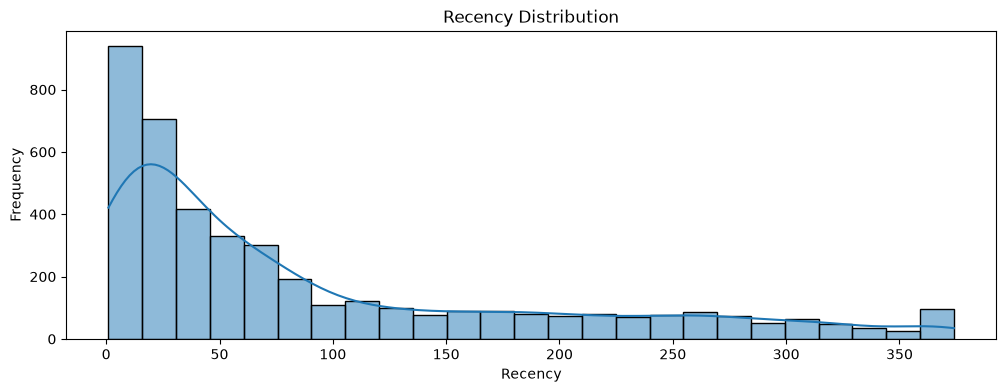

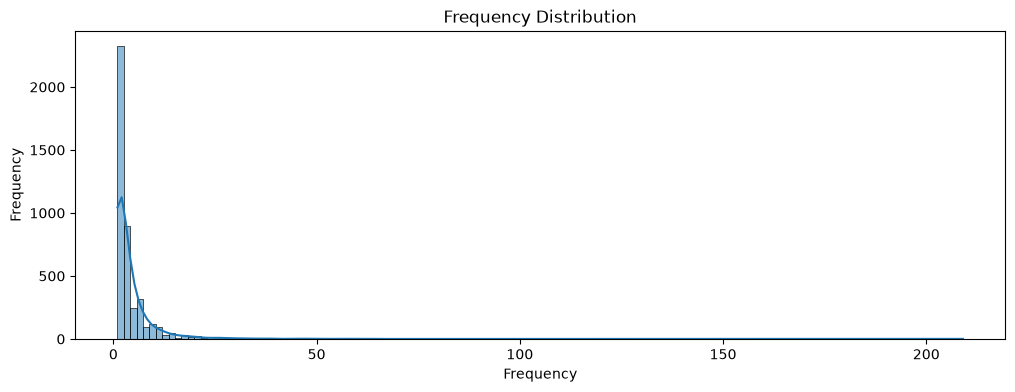

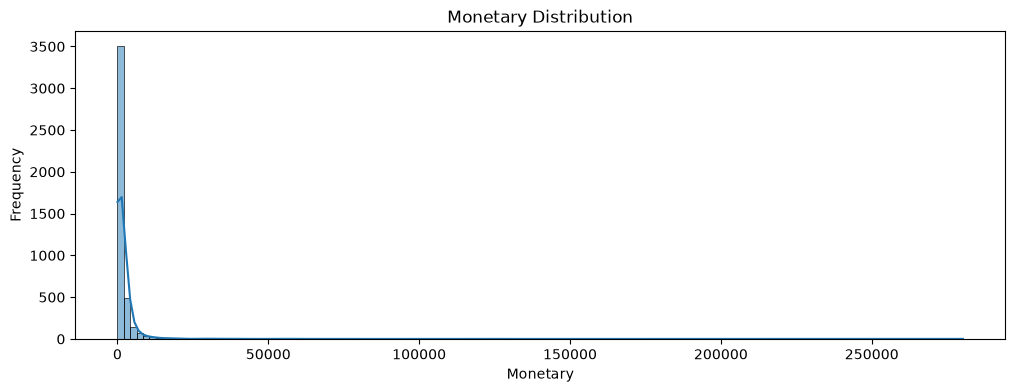

In [172]:
cols = ['Recency', 'Frequency', 'Monetary']

for col in cols:
    plt.figure(figsize=(12, 4))
    sns.histplot(data=rfm, x=col, kde=True)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

######

#### **RFM Feature Correlation Analysis**

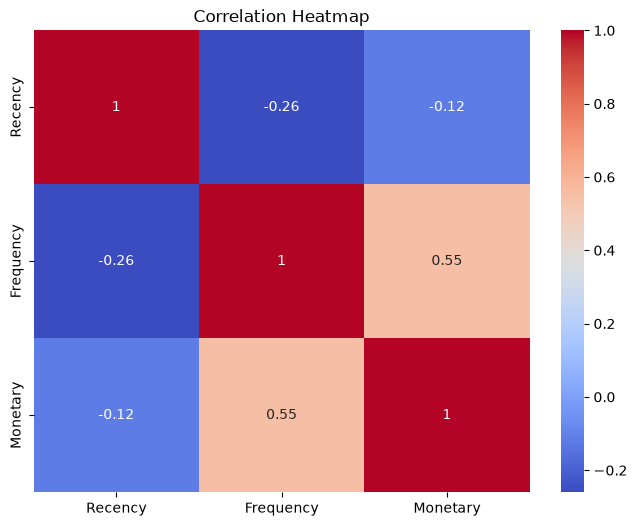

In [173]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    rfm[['Recency', 'Frequency', 'Monetary']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

#####

#### **RFM Outlier Analysis**

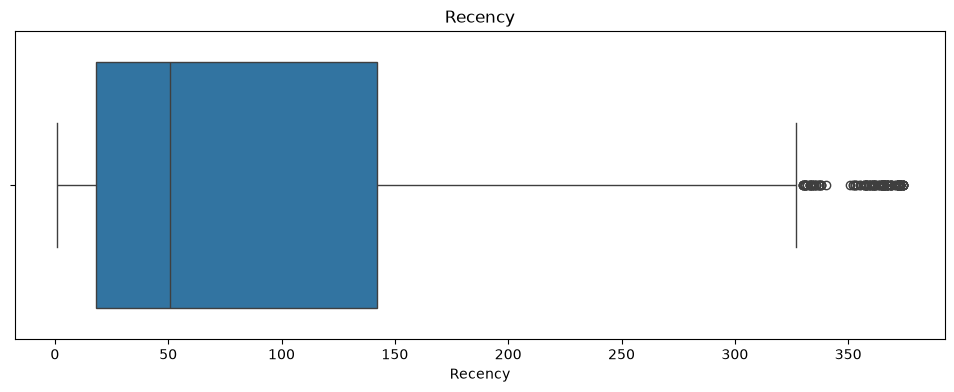

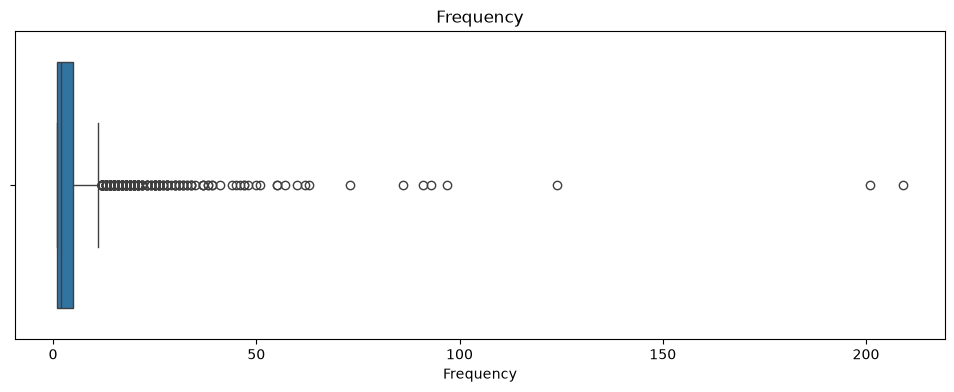

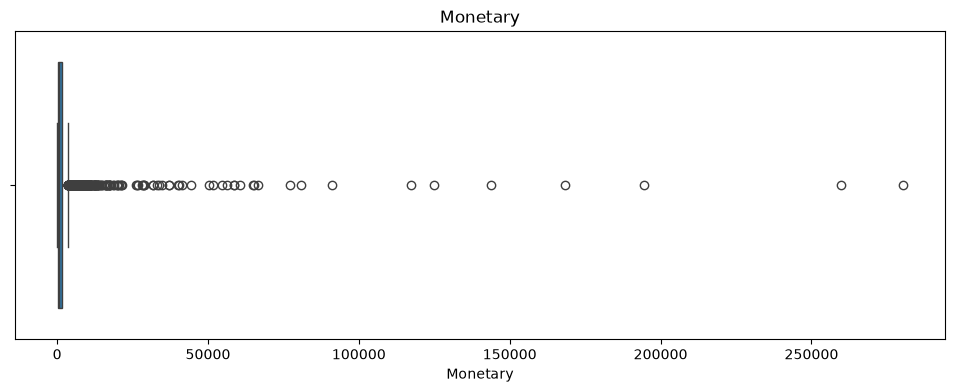

In [174]:
cols = ['Recency', 'Frequency', 'Monetary']

for col in cols:
    plt.figure(figsize=(12, 4))
    sns.boxplot(data=rfm, x=col)
    plt.title(col)
    plt.show()

#### **RFM Outlier Treatment Using IQR Clipping**

In [175]:
cols = ['Recency', 'Frequency', 'Monetary']

for col in cols:
    Q1 = rfm[col].quantile(0.25)
    Q3 = rfm[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    rfm[col] = rfm[col].clip(lower, upper)

###

#### **RFM Feature Scaling**

In [176]:
from sklearn.preprocessing import StandardScaler

scaled_cols = ['Recency', 'Frequency', 'Monetary']

scaler = StandardScaler()

X_scaled = rfm[scaled_cols].copy()

X_scaled[scaled_cols] = scaler.fit_transform(X_scaled)

#####

## **K-Means Clustering**

#### **Elbow Method for Optimal K**

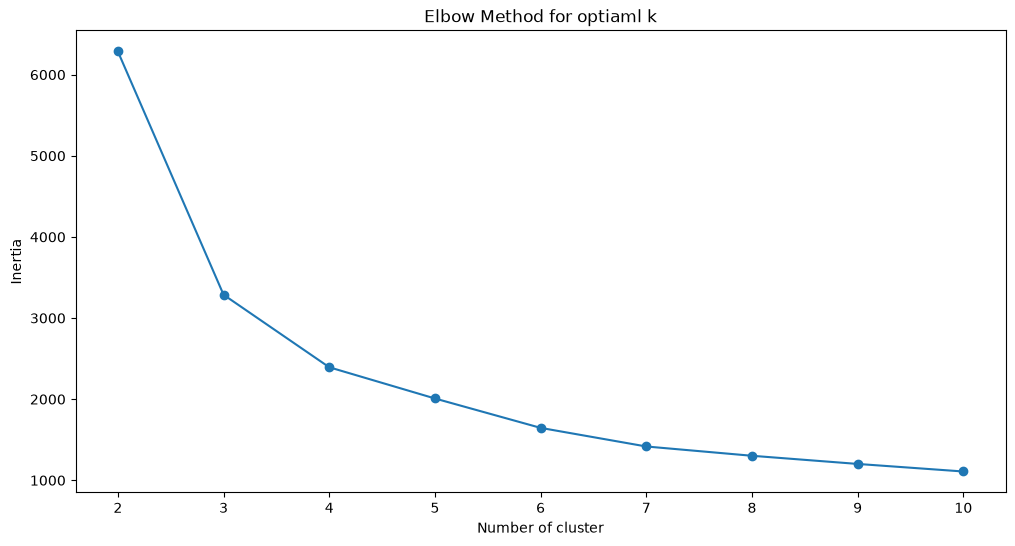

In [177]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(12, 6))
plt.plot(range(2, 11), inertia, marker='o')

plt.title("Elbow Method for optiaml k")
plt.xlabel("Number of cluster")
plt.ylabel("Inertia")
plt.show()

#### **Silhouette Score Analysis**

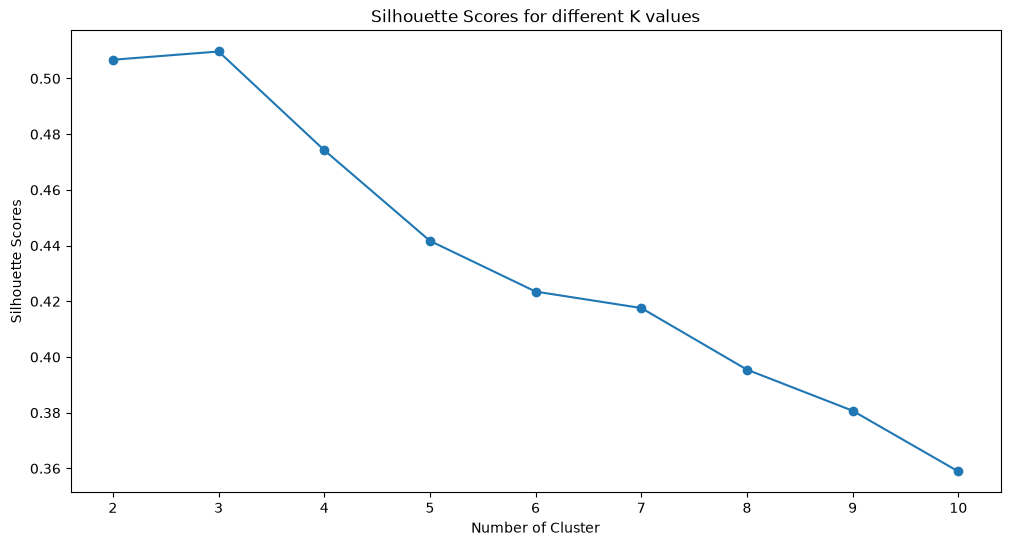

In [178]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(12, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o')

plt.title("Silhouette Scores for different K values")
plt.xlabel("Number of Cluster")
plt.ylabel("Silhouette Scores")
plt.show()

######

#### **Final K-Means Model with 3 Clusters**

In [179]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

#### **Final K-Means Model Evaluation**

In [180]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_calinski = calinski_harabasz_score(X_scaled, kmeans_labels)
kmeans_davies = davies_bouldin_score(X_scaled, kmeans_labels)

print("Silhouette Score:", round(kmeans_silhouette, 4))
print("Calinski-Harabasz Index:", round(kmeans_calinski, 4))
print("Davies-Bouldin Index:", round(kmeans_davies, 4))

Silhouette Score: 0.5097
Calinski-Harabasz Index: 6414.3748
Davies-Bouldin Index: 0.6681


#### **K-Means Baseline Cluster Distribution**

In [181]:
kmeans_cluster_distribution = (
    pd.Series(kmeans_labels)
    .value_counts()
    .sort_index()
)

kmeans_cluster_distribution

0    2328
1    1046
2     964
Name: count, dtype: int64

#### **K-Means Baseline Cluster Assignment**

In [182]:
rfm['Cluster'] = kmeans_labels

#### **K-Means Cluster Profiling & Customer Segment Analysis**

In [183]:
kmeans_profile = rfm.groupby('Cluster').agg(
    Customer_Count=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).reset_index()

kmeans_profile

,Cluster,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary
0,0,2328,49.110825,2.457474,726.143352
1,1,1046,245.161568,1.472275,426.574571
2,2,964,26.898340,8.157676,2999.082064


###

## **Hierarchical Clustering**

#### **Optimal Cluster Selection for Hierarchical Clustering**

In [184]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

hierarchial_scores = []

for k in range(2, 11):
    hierarchial = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hierarchial.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)

    hierarchial_scores.append({
        'K':k,
        'Silhouette Score':score
    })

hierarchial_scores = pd.DataFrame(hierarchial_scores)
hierarchial_scores

,K,Silhouette Score
0,2,0.509792
1,3,0.465100
2,4,0.440176
3,5,0.355860
4,6,0.355097
5,7,0.365520
6,8,0.377253
7,9,0.375567
8,10,0.366565


#### **Silhouette Score Analysis for Hierarchical Clustering**

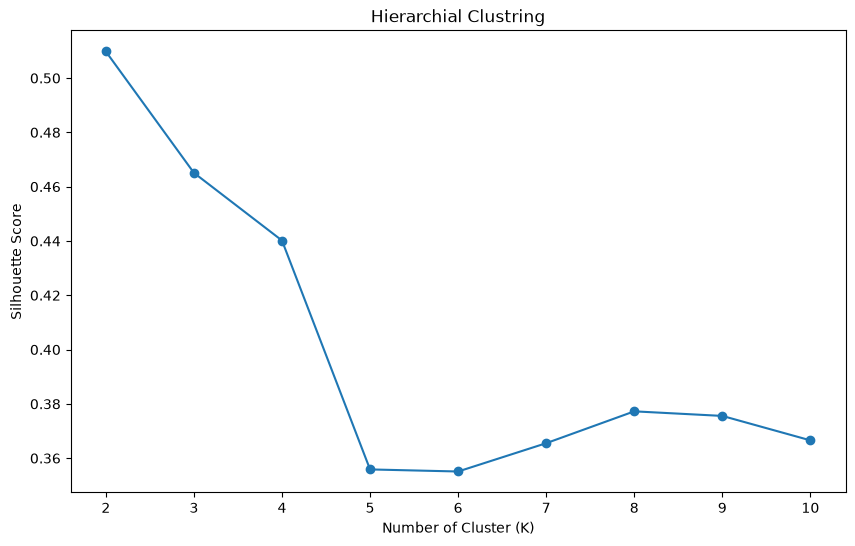

In [185]:
plt.figure(figsize=(10, 6))

plt.plot(
    hierarchial_scores['K'],
    hierarchial_scores['Silhouette Score'],
    marker='o'
)

plt.title("Hierarchial Clustring")
plt.xlabel("Number of Cluster (K)")
plt.ylabel("Silhouette Score")

plt.xticks(hierarchial_scores['K'])
plt.show()

#### **Hierarchical Clustering Dendrogram Analysis**

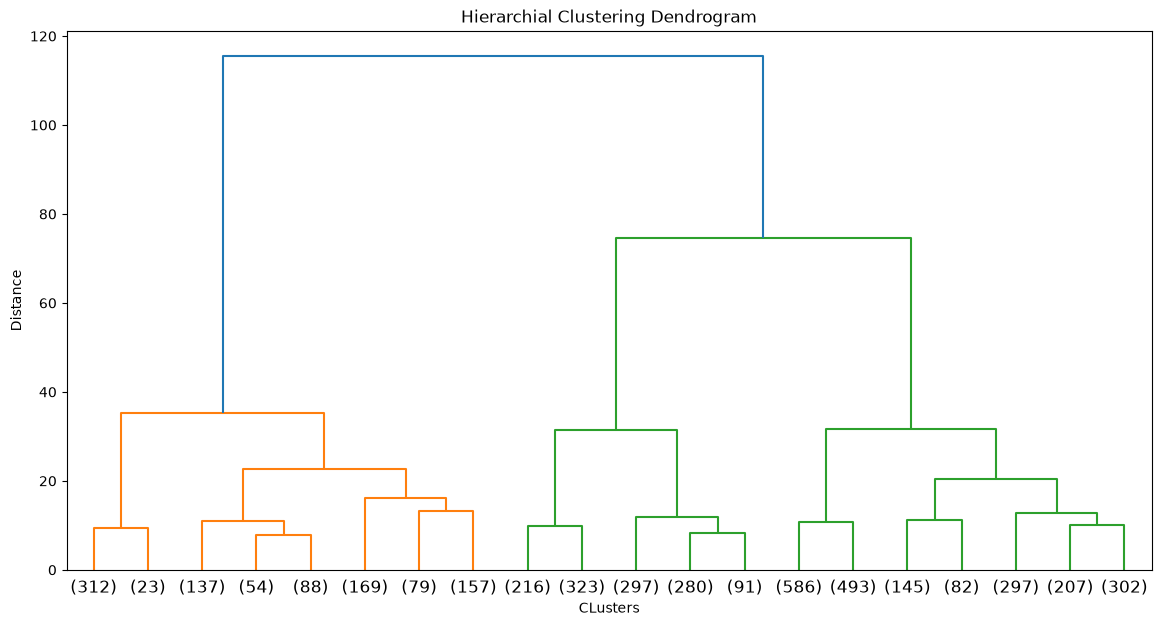

In [186]:
from scipy.cluster.hierarchy import dendrogram, linkage

linkage_matrix = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 7))

dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=20,
    show_leaf_counts=True
)

plt.title("Hierarchial Clustering Dendrogram")
plt.xlabel("CLusters")
plt.ylabel("Distance")
plt.show()

#### **Hierarchical Clustering Comparison for Optimal K Selection**

In [187]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

hierarchial_comparison = []

for k in [2, 3]:
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_scaled)

    hierarchial_comparison.append({
        'K':k,
        'Silhouette Score':silhouette_score(X_scaled, labels),
        'Calinski-Harabasz Index':calinski_harabasz_score(X_scaled, labels),
        'Davies-Bouldin Index':davies_bouldin_score(X_scaled, labels)
    })

hierarchial_comparison = pd.DataFrame(hierarchial_comparison)
hierarchial_comparison

,K,Silhouette Score,Calinski-Harabasz Index,Davies-Bouldin Index
0,2,0.509792,4543.771777,0.762918
1,3,0.465100,5712.805553,0.739640


#### **Hierarchical Baseline Cluster Distribution**

In [188]:
hierarchical_cluster_distributions = {}

for k in [2, 3]:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )
    
    labels = model.fit_predict(X_scaled)
    
    hierarchical_cluster_distributions[k] = (
        pd.Series(labels)
        .value_counts()
        .sort_index()
    )

hierarchical_cluster_distributions

{2: 0    3319
 1    1019
 Name: count, dtype: int64,
 3: 0    1019
 1    2112
 2    1207
 Name: count, dtype: int64}

#### **Hierarchical Clustering Cluster Profiling**

In [189]:
hierarchial_profiles = {}

for k in [2, 3]:
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_scaled)

    profile = rfm.copy()
    profile['Cluster'] = labels

    profile = profile.groupby('Cluster').agg(
        Customer_Count=('CustomerID', 'count'),
        Avg_Recency=('Recency', 'mean'),
        Avg_Frequency=('Frequency', 'mean'),
        Avg_Monetary=('Monetary', 'mean')
    ).reset_index()

    hierarchial_profiles[k] = profile

hierarchial_profiles

{2:    Cluster  Customer_Count  Avg_Recency  Avg_Frequency  Avg_Monetary
 0        0            3319   111.882495       2.088882    626.516226
 1        1            1019    24.888126       8.039254   2893.392031,
 3:    Cluster  Customer_Count  Avg_Recency  Avg_Frequency  Avg_Monetary
 0        0            1019    24.888126       8.039254   2893.392031
 1        1            2112    46.886837       2.460701    770.006773
 2        2            1207   225.611433       1.438277    375.437490}

#####

#### **Final Hierarchical Clustering Model with k=3**

In [190]:
hierarchial = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

hierarchial_labels = hierarchial.fit_predict(X_scaled)

#### **Hierarchical Clustering Model Evaluation**

In [191]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

hierarchical_silhouette = silhouette_score(X_scaled, hierarchial_labels)
hierarchical_calinski = calinski_harabasz_score(X_scaled, hierarchial_labels)
hierarchical_davies = davies_bouldin_score(X_scaled, hierarchial_labels)

print("Silhouette Score:", round(hierarchical_silhouette, 4))
print("Calinski-Harabasz Index:", round(hierarchical_calinski, 4))
print("Davies-Bouldin Index:", round(hierarchical_davies, 4))

Silhouette Score: 0.4651
Calinski-Harabasz Index: 5712.8056
Davies-Bouldin Index: 0.7396


#### **Hierarchical Baseline Cluster Distribution**

In [192]:
hierarchical_cluster_distribution = (
    pd.Series(hierarchial_labels)
    .value_counts()
    .sort_index()
)

hierarchical_cluster_distribution

0    1019
1    2112
2    1207
Name: count, dtype: int64

#### **Assign Hierarchical Cluster Labels to Customers**

In [193]:
rfm['Cluster'] = hierarchial_labels

#### **Hierarchical Clustering Profile**

In [194]:
hierarchical_profile = rfm.groupby('Cluster').agg(
    Customer_Count=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).reset_index()

hierarchical_profile

,Cluster,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary
0,0,1019,24.888126,8.039254,2893.392031
1,1,2112,46.886837,2.460701,770.006773
2,2,1207,225.611433,1.438277,375.437490


#### **Hierarchical Baseline Cluster Visualization**

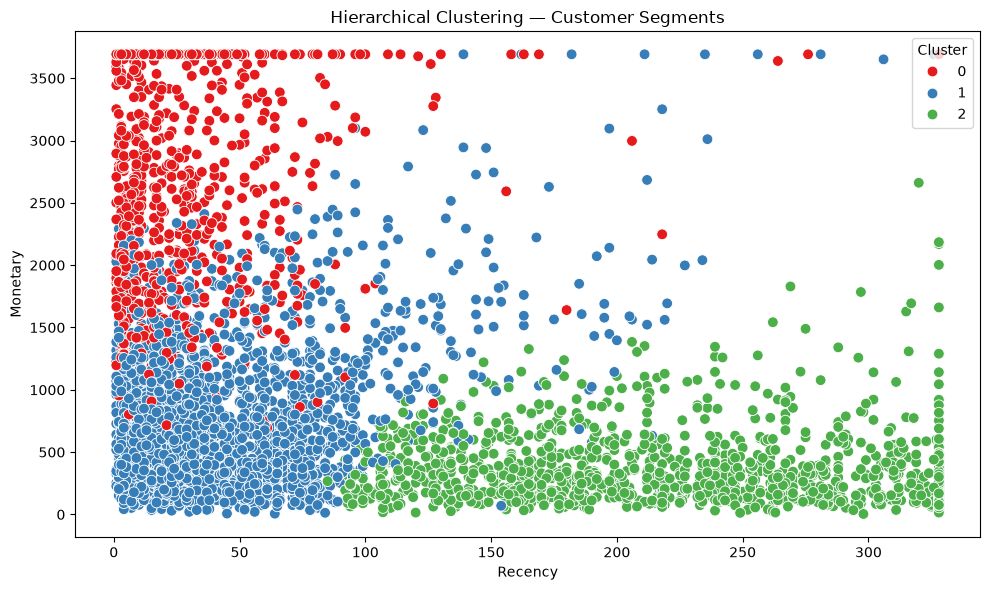

In [195]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set1',
    s=60
)

plt.title('Hierarchical Clustering — Customer Segments')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

####

## **DBSCAN Clustering**

#### **K-Distance Graph for DBSCAN Parameter Selection**

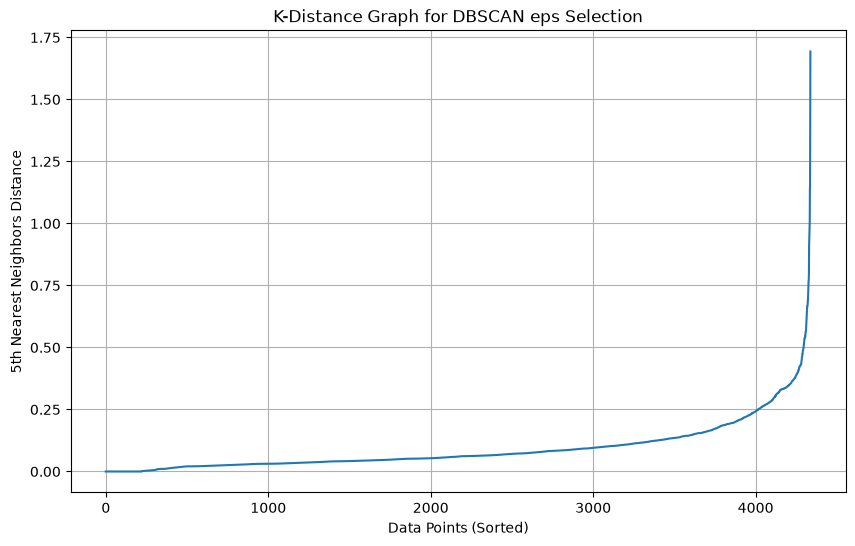

In [196]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(X_scaled)

distances, indices = neighbors.kneighbors(X_scaled)

k_distances = np.sort(distances[:, 4])

plt.figure(figsize=(10, 6))
plt.plot(k_distances)

plt.title("K-Distance Graph for DBSCAN eps Selection")
plt.xlabel("Data Points (Sorted)")
plt.ylabel("5th Nearest Neighbors Distance")

plt.grid()
plt.show()

######

#### **DBSCAN Epsilon Parameter Analysis**

In [197]:
from sklearn.cluster import DBSCAN

dbscan_results = []

for eps in [0.25, 0.30, 0.35, 0.40]:
    dbscan = DBSCAN(eps=eps, min_samples=5)

    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    dbscan_results.append({
        'eps':eps,
        'Clusters':n_clusters,
        'Noise Points': n_noise
    })

dbscan_results = pd.DataFrame(dbscan_results)
dbscan_results

,eps,Clusters,Noise Points
0,0.25,23,201
1,0.30,15,144
2,0.35,1,73
3,0.40,1,42


#### **DBSCAN Parameter Comparison for Epsilon Selection**

In [198]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

dbscan_comparison = []

for eps in [0.25, 0.30]:
    model = DBSCAN(eps=eps, min_samples=5)
    labels = model.fit_predict(X_scaled)

    mask = labels != -1

    dbscan_comparison.append({
        'eps':eps,
        'Clusters':len(set(labels)) - (1 if -1 in labels else 0),
        'Noise Points':list(labels).count(-1),
        'Silhouette Score':silhouette_score(X_scaled[mask], labels[mask]),
        'Calinski-Harabasz Index':calinski_harabasz_score(X_scaled[mask], labels[mask]),
        'Davies-Bouldin Index':davies_bouldin_score(X_scaled[mask], labels[mask])
    })

dbscan_comparison = pd.DataFrame(dbscan_comparison)
dbscan_comparison

,eps,Clusters,Noise Points,Silhouette Score,Calinski-Harabasz Index,Davies-Bouldin Index
0,0.25,23,201,-0.062324,480.522566,1.848952
1,0.30,15,144,0.016987,689.726561,2.411384


#### **DBSCAN Clustering with Selected Parameters**

In [199]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.30,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

#### **DBSCAN Clustering Model Evaluation**

In [200]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

mask = dbscan_labels != -1

dbscan_silhouette = silhouette_score(X_scaled[mask], dbscan_labels[mask])
dbscan_calinski = calinski_harabasz_score(X_scaled[mask], dbscan_labels[mask])
dbscan_davies = davies_bouldin_score(X_scaled[mask], dbscan_labels[mask])

print("Silhouette Score:", round(dbscan_silhouette, 4))
print("Calinski-Harabasz Index:", round(dbscan_calinski, 4))
print("Davies-Bouldin Index:", round(dbscan_davies, 4))

Silhouette Score: 0.017
Calinski-Harabasz Index: 689.7266
Davies-Bouldin Index: 2.4114


#### **DBSCAN Baseline Cluster Distribution**

In [201]:
dbscan_cluster_distribution = (
    pd.Series(dbscan_labels)
    .value_counts()
    .sort_index()
)

dbscan_cluster_distribution

-1      144
 0      133
 1      350
 2     1474
 3       91
 4      476
 5      813
 6       21
 7       52
 8      228
 9      153
 10     329
 11      23
 12      10
 13      38
 14       3
Name: count, dtype: int64

#### **Assign DBSCAN Cluster Labels to Customers**

In [202]:
rfm['Cluster'] = dbscan_labels

#### **DBSCAN Cluster Profiling**

In [203]:
dbscan_profile = rfm.groupby('Cluster').agg(
    Customer_Count=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).reset_index()

dbscan_profile

,Cluster,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary
0,-1,144,161.951389,4.645833,2274.682993
1,0,133,21.729323,7.000000,2480.714211
2,1,350,46.780000,4.000000,1220.527489
3,2,1474,153.381275,1.000000,326.910971
4,3,91,23.538462,8.000000,2495.353297
5,4,476,65.934874,3.000000,931.716725
6,5,813,92.840098,2.000000,608.664490
7,6,21,35.714286,4.000000,3661.538095
8,7,52,16.115385,10.000000,2862.592885
9,8,228,32.403509,5.000000,1753.559211


#### **DBSCAN Baseline Cluster Visualization**

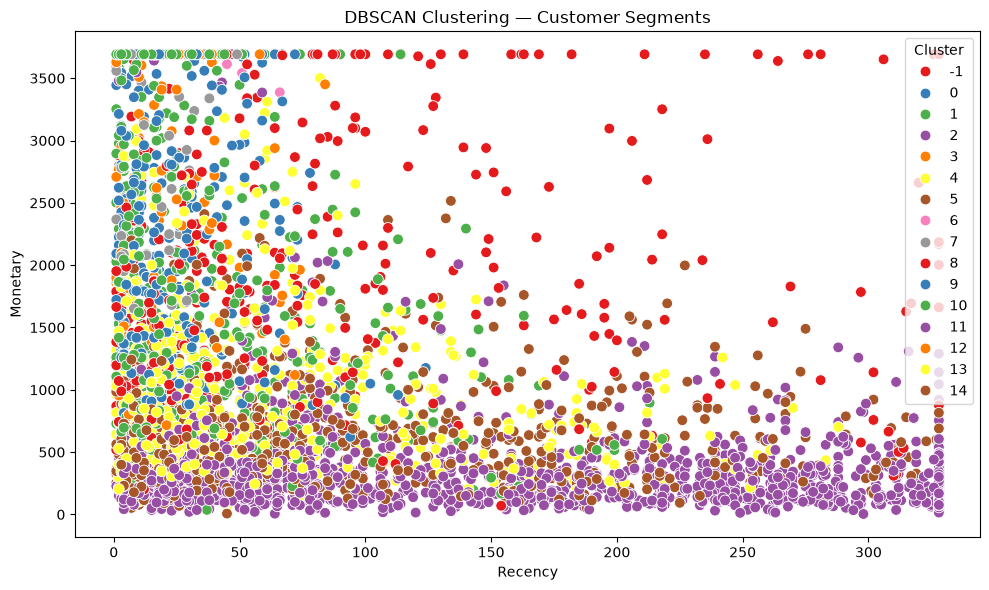

In [204]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set1',
    s=60
)

plt.title('DBSCAN Clustering — Customer Segments')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

####

## **Gaussian Mixture Model (GMM)**

#### **Gaussian Mixture Model Component Selection**

In [205]:
from sklearn.mixture import GaussianMixture

gmm_results = []

for n in range(2, 11):
    gmm = GaussianMixture(n_components=n, random_state=42)
    labels = gmm.fit_predict(X_scaled)

    gmm_results.append({
        'Components':n,
        'BIC':gmm.bic(X_scaled),
        'AIC':gmm.aic(X_scaled),
        'Silhouette Score':silhouette_score(X_scaled, labels)
    })

gmm_results = pd.DataFrame(gmm_results)
gmm_results

,Components,BIC,AIC,Silhouette Score
0,2,23855.351296,23734.223091,0.372065
1,3,21885.158164,21700.278272,0.234817
2,4,16989.703140,16741.071562,0.209886
3,5,1229.335533,916.952267,0.129537
4,6,-4610.682355,-4986.817308,0.066227
5,7,-7161.601420,-7601.488060,0.068307
6,8,-14750.433589,-15254.071916,0.044252
7,9,-9092.490095,-9659.880109,0.011691
8,10,-16706.795371,-17337.937071,-0.013044


#### **GMM Model Selection Metrics Visualization**

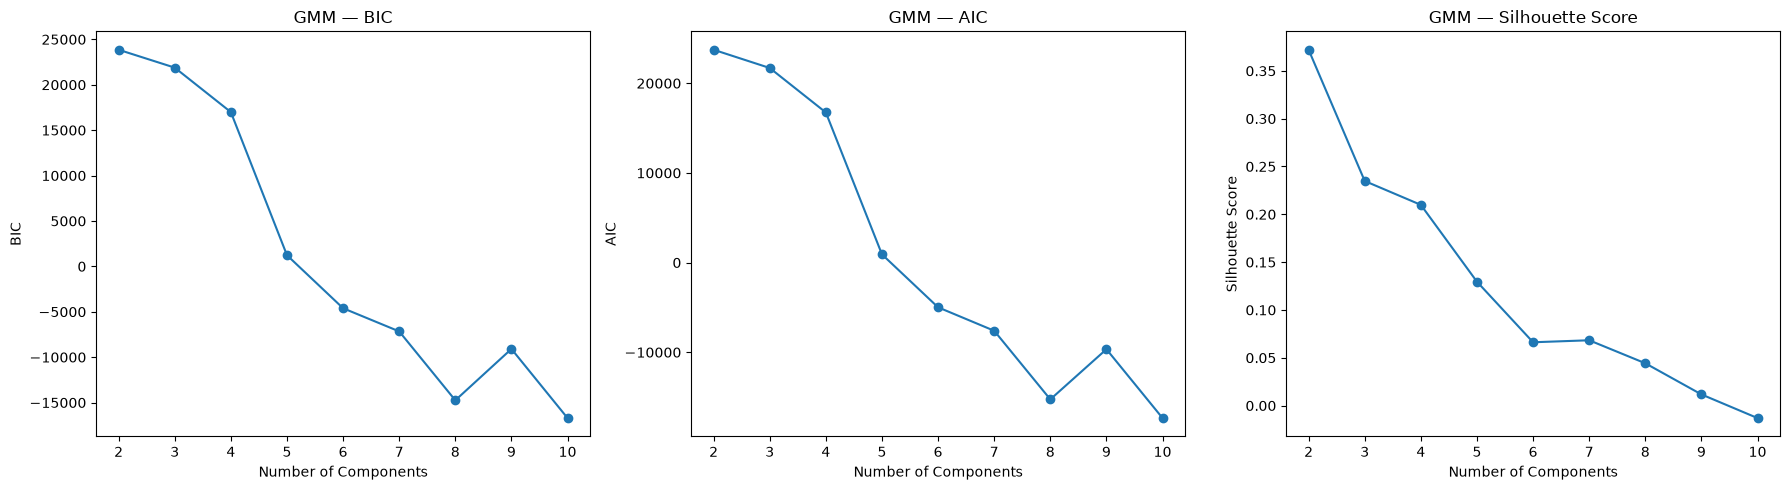

In [206]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(
    gmm_results['Components'],
    gmm_results['BIC'],
    marker='o'
)
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('BIC')
axes[0].set_title('GMM — BIC')

axes[1].plot(
    gmm_results['Components'],
    gmm_results['AIC'],
    marker='o'
)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('AIC')
axes[1].set_title('GMM — AIC')

axes[2].plot(
    gmm_results['Components'],
    gmm_results['Silhouette Score'],
    marker='o'
)
axes[2].set_xlabel('Number of Components')
axes[2].set_ylabel('Silhouette Score')
axes[2].set_title('GMM — Silhouette Score')

plt.tight_layout()
plt.show()

#### **GMM Components Comparison**

In [207]:
gmm_comparison = []

for n in [2, 3]:
    model = GaussianMixture(
        n_components=n,
        random_state=42
    )

    labels = model.fit_predict(X_scaled)

    gmm_comparison.append({
        'Components': n,
        'BIC': model.bic(X_scaled),
        'AIC': model.aic(X_scaled),
        'Silhouette Score': silhouette_score(X_scaled, labels),
        'Calinski-Harabasz Index': calinski_harabasz_score(X_scaled, labels),
        'Davies-Bouldin Index': davies_bouldin_score(X_scaled, labels)
    })

gmm_comparison = pd.DataFrame(gmm_comparison)

gmm_comparison

,Components,BIC,AIC,Silhouette Score,Calinski-Harabasz Index,Davies-Bouldin Index
0,2,23855.351296,23734.223091,0.372065,3312.856627,1.050568
1,3,21885.158164,21700.278272,0.234817,2272.633886,1.062240


#### **Gaussian Mixture Model Clustering**

In [208]:
gmm = GaussianMixture(
    n_components=2,
    random_state=42
)

gmm_labels = gmm.fit_predict(X_scaled)

#### **GMM Clustering Model Evaluation**

In [209]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

gmm_silhouette = silhouette_score(X_scaled, gmm_labels)
gmm_calinski = calinski_harabasz_score(X_scaled, gmm_labels)
gmm_davies = davies_bouldin_score(X_scaled, gmm_labels)

print("Silhouette Score:", round(gmm_silhouette, 4))
print("Calinski-Harabasz Index:", round(gmm_calinski, 4))
print("Davies-Bouldin Index:", round(gmm_davies, 4))

Silhouette Score: 0.3721
Calinski-Harabasz Index: 3312.8566
Davies-Bouldin Index: 1.0506


#### **GMM Baseline Cluster Distribution**

In [210]:
gmm_cluster_distribution = (
    pd.Series(gmm_labels)
    .value_counts()
    .sort_index()
)

gmm_cluster_distribution

0    1903
1    2435
Name: count, dtype: int64

#### **Assign GMM Cluster Labels to Customers**

In [211]:
rfm['Cluster'] = gmm_labels

#### **GMM Cluster Profiling**

In [212]:
gmm_profile = rfm.groupby('Cluster').agg(
    Customer_Count=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).reset_index()

gmm_profile

,Cluster,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary
0,0,1903,41.035733,5.96269,2138.728078
1,1,2435,130.845175,1.55154,393.336469


#### **GMM Baseline Cluster Visualization**

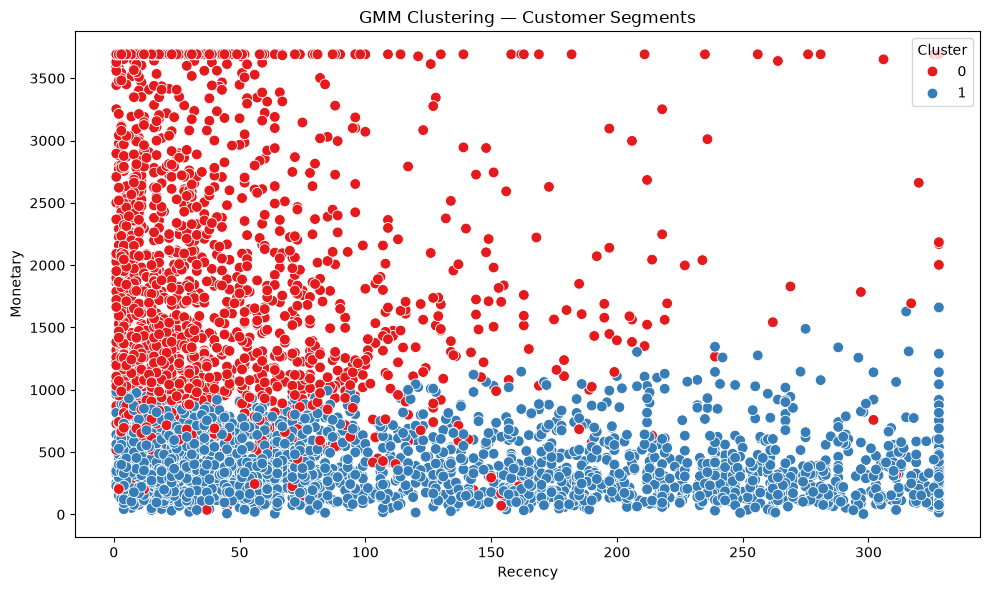

In [213]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set1',
    s=60
)

plt.title('GMM Clustering — Customer Segments')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

####

#### **Clustering Model Performance Comparison**

In [214]:
comparison_df = pd.DataFrame({
    "Model": [
        'K-Means',
        'Hierarchical',
        'DBSCAN',
        'GMM'
    ],
    "Silhouette Score": [
        kmeans_silhouette,
        hierarchical_silhouette,
        dbscan_silhouette,
        gmm_silhouette
    ],
    "Calinski-Harabasz Index": [
        kmeans_calinski,
        hierarchical_calinski,
        dbscan_calinski,
        gmm_calinski
    ],
    "Davies-Bouldin Index": [
        kmeans_davies,
        hierarchical_davies,
        dbscan_davies,
        gmm_davies
    ]
})

comparison_df

,Model,Silhouette Score,Calinski-Harabasz Index,Davies-Bouldin Index
0,K-Means,0.509691,6414.374820,0.668082
1,Hierarchical,0.465100,5712.805553,0.739640
2,DBSCAN,0.016987,689.726561,2.411384
3,GMM,0.372065,3312.856627,1.050568


#### **Clustering Model Performance Visualization**

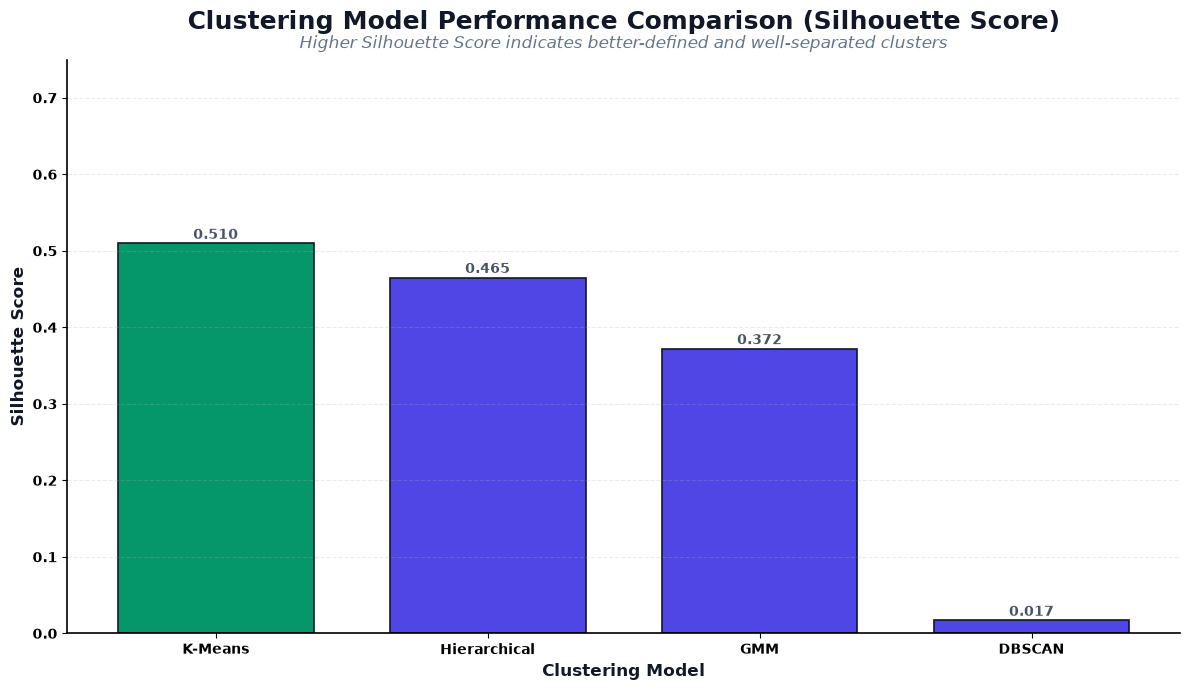

In [215]:
import matplotlib.pyplot as plt

# Sort by Silhouette Score — highest to lowest
plot_df = comparison_df.sort_values(
    by='Silhouette Score',
    ascending=False
).reset_index(drop=True)

plt.figure(figsize=(12, 7))

colors = ['#4F46E5'] * len(plot_df)

# Highest best model
best_index = plot_df['Silhouette Score'].idxmax()

colors[best_index] = '#059669'

bars = plt.bar(
    plot_df["Model"],
    plot_df["Silhouette Score"],
    color=colors,
    edgecolor='#111827',
    linewidth=1.2,
    width=0.72
)

plt.title(
    "Clustering Model Performance Comparison (Silhouette Score)",
    fontsize=18,
    fontweight='bold',
    color='#111827',
    pad=22
)

plt.text(
    0.5, 1.02,
    "Higher Silhouette Score indicates better-defined and well-separated clusters",
    transform=plt.gca().transAxes,
    ha='center',
    fontsize=12,
    color='#64748B',
    style='italic'
)

plt.xlabel(
    "Clustering Model",
    fontsize=12,
    fontweight='bold',
    color='#111827'
)

plt.ylabel(
    "Silhouette Score",
    fontsize=12,
    fontweight='bold',
    color='#111827'
)

plt.grid(
    axis='y',
    linestyle='--',
    linewidth=0.8,
    alpha=0.25
)

plt.xticks(
    rotation=0,
    fontsize=10,
    fontweight='bold'
)

plt.yticks(
    fontsize=10,
    fontweight='bold'
)

# Remove top/right border
ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# Top values
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.006,
        f"{height:.3f}",
        ha='center',
        fontsize=10,
        fontweight='bold',
        color='#475569'
    )

plt.ylim(0, 0.75)

plt.tight_layout()
plt.show()

####

#### **K-Means Hyperparameter Tuning**

In [216]:
from sklearn.model_selection import ParameterGrid
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

param_grid = {
    'n_clusters': [2, 3, 4, 5],
    'init': ['k-means++', 'random'],
    'n_init': [10, 20],
    'max_iter': [300, 500],
    'tol': [1e-4, 1e-3]
}

kmeans_results =[]

for params in ParameterGrid(param_grid):
    model = KMeans(
        random_state=42,
        **params
    )

    labels = model.fit_predict(X_scaled)

    kmeans_results.append({
        **params,
        'Inertia':model.inertia_,
        'Silhouette Score':silhouette_score(X_scaled, labels),
        'Calinski-Harabasz Score': calinski_harabasz_score(X_scaled, labels),
        'Davies-Bouldin Score':davies_bouldin_score(X_scaled, labels)
    })

kmeans_results = pd.DataFrame(kmeans_results)

kmeans_results = kmeans_results.sort_values(by='Silhouette Score', ascending=False).reset_index(drop=True)
kmeans_results.head(10)

,init,max_iter,n_clusters,n_init,tol,Inertia,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score
0,k-means++,300,3,20,0.0010,3286.925320,0.509691,6414.374820,0.668082
1,k-means++,300,3,20,0.0001,3286.925320,0.509691,6414.374820,0.668082
2,k-means++,300,3,10,0.0010,3286.925320,0.509691,6414.374820,0.668082
3,k-means++,300,3,10,0.0001,3286.925320,0.509691,6414.374820,0.668082
4,k-means++,500,3,10,0.0001,3286.925320,0.509691,6414.374820,0.668082
5,k-means++,500,3,10,0.0010,3286.925320,0.509691,6414.374820,0.668082
6,k-means++,500,3,20,0.0001,3286.925320,0.509691,6414.374820,0.668082
7,k-means++,500,3,20,0.0010,3286.925320,0.509691,6414.374820,0.668082
8,random,500,3,20,0.0001,3286.903191,0.509571,6414.394956,0.668477
9,random,500,3,10,0.0001,3286.903191,0.509571,6414.394956,0.668477


#### **K-Means Model Training with Optimized Parameters**

In [217]:
kmeans_tuned = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=10,
    max_iter=300,
    tol=0.0001,
    random_state=42
)

kmeans_tuned_labels = kmeans_tuned.fit_predict(X_scaled)

#### **Tuned K-Means Model Evaluation**

In [218]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

kmeans_tuned_silhouette = silhouette_score(X_scaled, kmeans_tuned_labels)
kmeans_tuned_calinski = calinski_harabasz_score(X_scaled, kmeans_tuned_labels)
kmeans_tuned_davies = davies_bouldin_score(X_scaled, kmeans_tuned_labels)

print("Silhouette Score:", round(kmeans_tuned_silhouette, 4))
print("Calinski-Harabasz Score:", round(kmeans_tuned_calinski, 4))
print("Davies-Bouldin Score:", round(kmeans_tuned_davies, 4))

Silhouette Score: 0.5097
Calinski-Harabasz Score: 6414.3748
Davies-Bouldin Score: 0.6681


#### **Tuned K-Means Cluster Distribution**

In [219]:
kmeans_tuned_distribution = (
    pd.Series(kmeans_tuned_labels)
    .value_counts()
    .sort_index()
)

kmeans_tuned_distribution

0    2328
1    1046
2     964
Name: count, dtype: int64

#### **Tuned K-Means Cluster Profile**

In [220]:
rfm['Cluster'] = kmeans_tuned_labels

kmeans_tuned_profile = rfm.groupby('Cluster').agg(
    Customer_Count=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).reset_index()

kmeans_tuned_profile

,Cluster,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary
0,0,2328,49.110825,2.457474,726.143352
1,1,1046,245.161568,1.472275,426.574571
2,2,964,26.898340,8.157676,2999.082064


#### **Tuned K-Means Cluster Visualization**

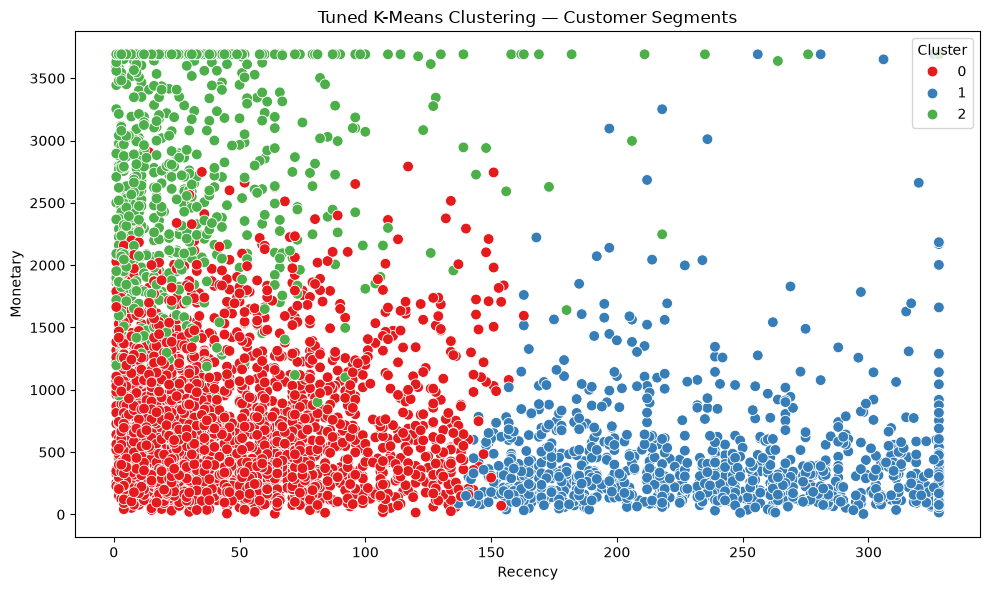

In [221]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set1',
    s=60
)

plt.title('Tuned K-Means Clustering — Customer Segments')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

####

#### **Hierarchical Clustering Hyperparameter Tuning**

In [222]:
from sklearn.model_selection import ParameterGrid
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

param_grid = {
    'n_clusters': [2, 3, 4, 5],
    'linkage': ['ward', 'complete', 'average', 'single'],
    'metric': ['euclidean', 'manhattan', 'cosine']
}

hierarchical_results = []

for params in ParameterGrid(param_grid):

    # Ward linkage supports only Euclidean distance
    if params['linkage'] == 'ward' and params['metric'] != 'euclidean':
        continue

    model = AgglomerativeClustering(
        **params
    )

    labels = model.fit_predict(X_scaled)

    hierarchical_results.append({
        **params,
        'Silhouette Score': silhouette_score(X_scaled, labels),
        'Calinski-Harabasz Score': calinski_harabasz_score(X_scaled, labels),
        'Davies-Bouldin Score': davies_bouldin_score(X_scaled, labels)
    })

hierarchical_results = pd.DataFrame(hierarchical_results)

hierarchical_results = hierarchical_results.sort_values(
    by='Silhouette Score',
    ascending=False
).reset_index(drop=True)

hierarchical_results.head(10)

,linkage,metric,n_clusters,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score
0,average,manhattan,2,0.520767,4140.285687,0.702080
1,average,euclidean,2,0.518342,4436.695215,0.733080
2,complete,euclidean,2,0.511764,3770.085888,0.661449
3,ward,euclidean,2,0.509792,4543.771777,0.762918
4,single,euclidean,2,0.493728,5.643530,0.372724
5,single,manhattan,2,0.493728,5.643530,0.372724
6,complete,euclidean,3,0.465107,4967.420183,0.668997
7,ward,euclidean,3,0.465100,5712.805553,0.739640
8,average,euclidean,3,0.452027,2290.412171,0.702687
9,average,manhattan,5,0.451992,3019.987959,0.795619


#### **Hierarchical Clustering Model Training with Optimized Parameters**

In [223]:
hierarchical_tuned = AgglomerativeClustering(
    n_clusters=2,
    linkage='average',
    metric='manhattan'
)

hierarchical_tuned_labels = hierarchical_tuned.fit_predict(X_scaled)

#### **Tuned Hierarchical Clustering Evaluation**

In [224]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

hierarchaical_tuned_silhouette = silhouette_score(X_scaled, hierarchical_tuned_labels)
hierarchaical_tuned_calinski = calinski_harabasz_score(X_scaled, hierarchical_tuned_labels)
hierarchaical_tuned_davies = davies_bouldin_score(X_scaled, hierarchical_tuned_labels)

print("Silhouette Score:", round(hierarchaical_tuned_silhouette, 4))
print("Calinski-Harabasz Score:", round(hierarchaical_tuned_calinski, 4))
print("Davies-Bouldin Score:", round(hierarchaical_tuned_davies, 4))

Silhouette Score: 0.5208
Calinski-Harabasz Score: 4140.2857
Davies-Bouldin Score: 0.7021


#### **Tuned Hierarchical Cluster Distribution**

In [225]:
hierarchical_tuned_distribution = (
    pd.Series(hierarchical_tuned_labels)
    .value_counts()
    .sort_index()
)

hierarchical_tuned_distribution

0    3526
1     812
Name: count, dtype: int64

#### **Tuned Hierarchical Cluster Profile**

In [226]:
rfm['Cluster'] = hierarchical_tuned_labels

hierarchical_tuned_profile = rfm.groupby('Cluster').agg(
    Customer_Count=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).reset_index()

hierarchical_tuned_profile

,Cluster,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary
0,0,3526,106.804878,2.323029,691.889556
1,1,812,24.759852,8.539409,3187.403030


#### **Tuned Hierarchical Cluster Visualization**

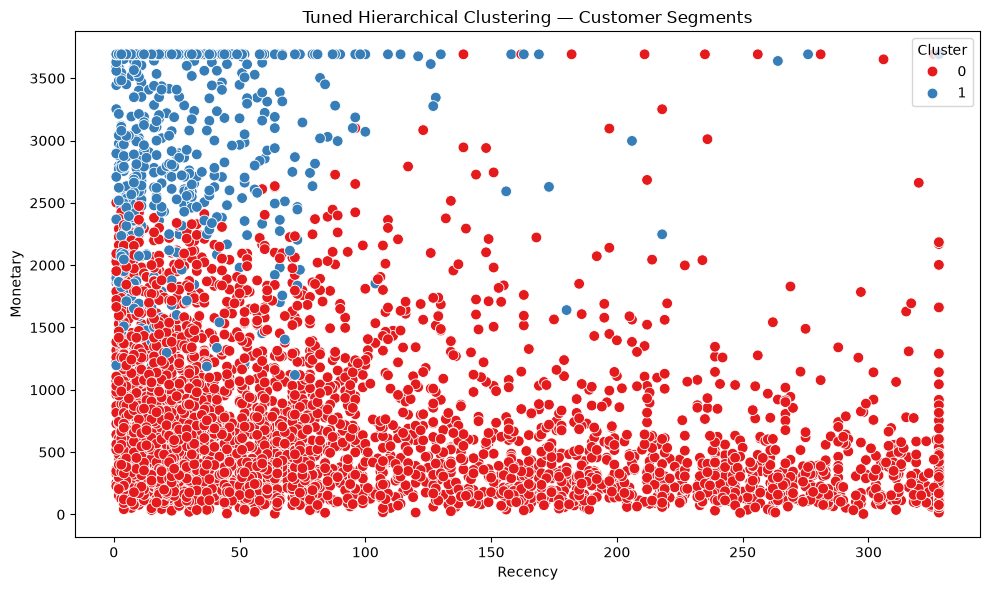

In [227]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set1',
    s=60
)

plt.title('Tuned Hierarchical Clustering — Customer Segments')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

####

#### **DBSCAN Hyperparameter Tuning Results**

In [228]:
from sklearn.model_selection import ParameterGrid
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

dbscan_param_grid = {
    'eps': [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    'min_samples': [3, 5, 7, 10, 15],
    'metric': ['euclidean', 'manhattan', 'cosine']
}

dbscan_results = []

for params in ParameterGrid(dbscan_param_grid):
    model = DBSCAN(**params)
    labels = model.fit_predict(X_scaled)

    # Ignore noise points
    mask = labels != -1
    filtered_labels = labels[mask]
    filtered_data = X_scaled[mask]

    # Need at least 2 clusters for evaluation
    if len(set(filtered_labels)) < 2:
        continue

    dbscan_results.append({
        **params,
        'Clusters': len(set(filtered_labels)),
        'Noise Points': sum(labels == -1),
        'Silhouette Score': silhouette_score(filtered_data, filtered_labels),
        'Calinski-Harabasz Score': calinski_harabasz_score(filtered_data, filtered_labels),
        'Davies-Bouldin Score': davies_bouldin_score(filtered_data, filtered_labels)
    })

dbscan_results = pd.DataFrame(dbscan_results)

dbscan_results = dbscan_results.sort_values(
    by='Silhouette Score',
    ascending=False
).reset_index(drop=True)

dbscan_results.head(10)

,eps,metric,min_samples,Clusters,Noise Points,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score
0,0.6,euclidean,7,2,17,0.303232,15.281160,0.752984
1,0.5,euclidean,3,2,17,0.277026,20.898158,0.866106
2,0.5,euclidean,5,2,25,0.239313,8.254840,0.847399
3,0.5,manhattan,3,2,44,0.201066,11.224303,0.753408
4,0.3,manhattan,15,16,605,0.042793,673.785370,1.565919
5,0.2,euclidean,10,21,598,0.042567,519.748924,1.360058
6,0.3,euclidean,15,19,420,0.035203,595.663129,1.690525
7,0.4,euclidean,3,2,33,0.025751,1.760774,1.316127
8,0.3,manhattan,10,19,415,0.022244,587.890759,1.678856
9,0.3,euclidean,7,16,188,0.020225,672.821433,2.261443


#### **DBSCAN Model Training with Optimized Parameters**

In [229]:
dbscan_tuned = DBSCAN(
    eps=0.6,
    min_samples=7,
    metric='euclidean'
)

dbscan_tuned_labels = dbscan_tuned.fit_predict(X_scaled)

#### **DBSCAN Tuned Model Evaluation**

In [230]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

mask = dbscan_tuned_labels != -1

dbscan_tuned_silhouette_score = silhouette_score(X_scaled[mask], dbscan_tuned_labels[mask])
dbscan_tuned_calinski = calinski_harabasz_score(X_scaled[mask], dbscan_tuned_labels[mask])
dbscan_tuned_davies = davies_bouldin_score(X_scaled[mask], dbscan_tuned_labels[mask])

print("Silhouette Score:", round(dbscan_tuned_silhouette_score, 4))
print("Calinski-Harabasz Score:", round(dbscan_tuned_calinski, 4))
print("Davies-Bouldin Score:", round(dbscan_tuned_davies, 4))

Silhouette Score: 0.3032
Calinski-Harabasz Score: 15.2812
Davies-Bouldin Score: 0.753


#### **Tuned DBSCAN Cluster Distribution**

In [231]:
dbscan_tuned_distribution = (
    pd.Series(dbscan_tuned_labels)
    .value_counts()
    .sort_index()
)

dbscan_tuned_distribution

-1      17
 0    4314
 1       7
Name: count, dtype: int64

#### **Tuned DBSCAN Cluster Profile**

In [232]:
rfm['Cluster'] = dbscan_tuned_labels

dbscan_tuned_profile = rfm.groupby('Cluster').agg(
    Customer_Count=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).reset_index()

dbscan_tuned_profile

,Cluster,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary
0,-1,17,229.588235,6.823529,2772.388824
1,0,4314,90.676171,3.474965,1148.799852
2,1,7,231.285714,2.571429,3531.523000


#### **Tuned DBSCAN Cluster Visualization**

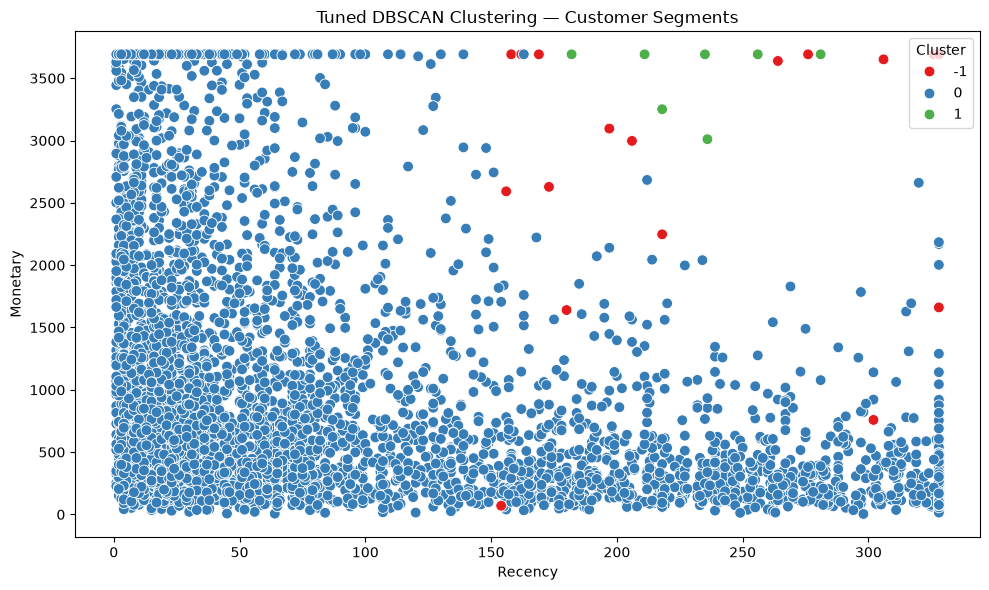

In [233]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set1',
    s=60
)

plt.title('Tuned DBSCAN Clustering — Customer Segments')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

####

#### **GMM Hyperparameter Tuning Results**

In [234]:
from sklearn.model_selection import ParameterGrid
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

gmm_param_grid = {
    'n_components': [2, 3, 4, 5],
    'covariance_type': ['full', 'tied', 'diag', 'spherical'],
    'reg_covar': [1e-6, 1e-5, 1e-4],
    'init_params': ['kmeans', 'random']
}

gmm_results = []

for params in ParameterGrid(gmm_param_grid):

    model = GaussianMixture(random_state=42, **params)

    labels = model.fit_predict(X_scaled)
    if len(set(labels)) < 2:
        continue

    gmm_results.append({
        **params,
        'Silhouette Score': silhouette_score(X_scaled, labels),
        'Calinski-Harabasz Score': calinski_harabasz_score(X_scaled, labels),
        'Davies-Bouldin Score': davies_bouldin_score(X_scaled, labels),
        'BIC': model.bic(X_scaled),
        'AIC': model.aic(X_scaled)
    })

gmm_results = pd.DataFrame(gmm_results)

gmm_results = gmm_results.sort_values(
    by='Silhouette Score',
    ascending=False
).reset_index(drop=True)

gmm_results.head(10)

,covariance_type,init_params,n_components,reg_covar,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score,BIC,AIC
0,spherical,kmeans,2,0.000001,0.524530,4362.054862,0.691640,31905.943359,31848.566841
1,spherical,kmeans,2,0.000010,0.524530,4362.054862,0.691640,31905.943080,31848.566562
2,spherical,kmeans,2,0.000100,0.524530,4362.054862,0.691640,31905.940537,31848.564019
3,spherical,kmeans,3,0.000001,0.498993,5908.042726,0.687337,26136.689974,26047.437612
4,spherical,kmeans,3,0.000100,0.498993,5908.042726,0.687337,26136.843270,26047.590909
5,spherical,kmeans,3,0.000010,0.498993,5908.042726,0.687337,26136.703730,26047.451368
6,tied,kmeans,2,0.000100,0.489668,3525.033988,0.787772,28358.720780,28275.843587
7,tied,kmeans,2,0.000001,0.489668,3525.033988,0.787772,28358.628611,28275.751418
8,tied,kmeans,2,0.000010,0.489668,3525.033988,0.787772,28358.636757,28275.759564
9,tied,kmeans,3,0.000100,0.481332,5194.468141,0.690142,25948.439498,25840.061630


#### **GMM Model Training with Optimized Parameters**

In [235]:
gmm_tuned = GaussianMixture(
    n_components=2,
    covariance_type='spherical',
    reg_covar=1e-6,
    init_params='kmeans',
    random_state=42
)

gmm_tuned_labels = gmm_tuned.fit_predict(X_scaled)

#### **GMM Tuned Model Evaluation**

In [236]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

gmm_tuned_silhouette_score = silhouette_score(X_scaled, gmm_tuned_labels)
gmm_tuned_calinski = calinski_harabasz_score(X_scaled, gmm_tuned_labels)
gmm_tuned_davies = davies_bouldin_score(X_scaled, gmm_tuned_labels)

print("Silhouette Score:", round(gmm_tuned_silhouette_score, 4))
print("Calinski-Harabasz Score:", round(gmm_tuned_calinski, 4))
print("Davies-Bouldin Score:", round(gmm_tuned_davies, 4))

Silhouette Score: 0.5245
Calinski-Harabasz Score: 4362.0549
Davies-Bouldin Score: 0.6916


#### **Tuned GMM Cluster Distribution**

In [237]:
gmm_tuned_distribution = (
    pd.Series(gmm_tuned_labels)
    .value_counts()
    .sort_index()
)

gmm_tuned_distribution

0     844
1    3494
Name: count, dtype: int64

#### **Tuned GMM Cluster Profile**

In [238]:
rfm['Cluster'] = gmm_tuned_labels

gmm_tuned_profile = rfm.groupby('Cluster').agg(
    Customer_Count=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).reset_index()

gmm_tuned_profile

,Cluster,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary
0,0,844,22.957346,8.620853,3104.550640
1,1,3494,107.991700,2.246422,689.047823


#### **Tuned GMM Cluster Visualization**

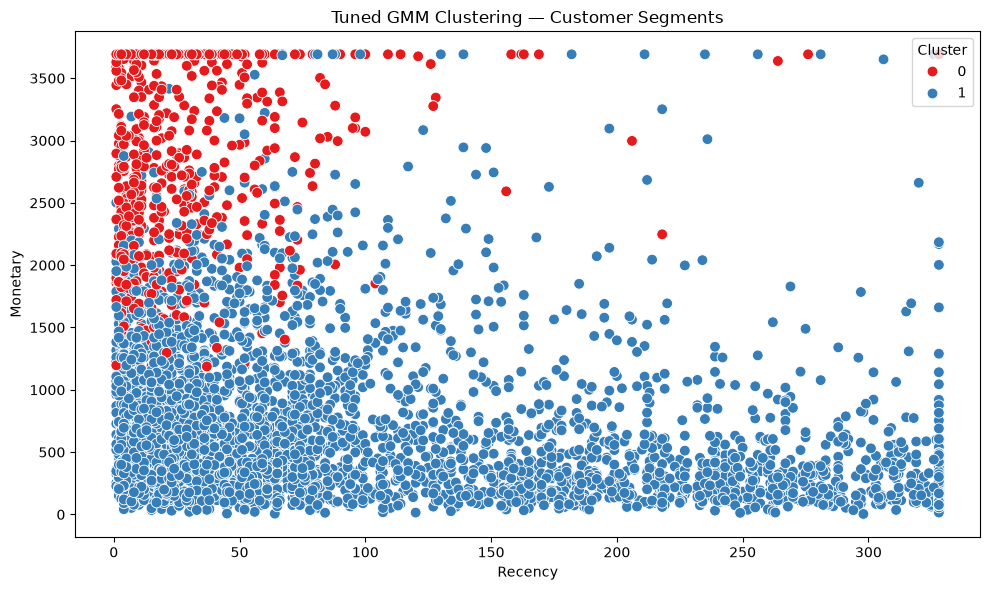

In [239]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set1',
    s=60
)

plt.title('Tuned GMM Clustering — Customer Segments')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

####

#### **Tuned Model Performance Comparison**

In [240]:
comparison_tuned_df = pd.DataFrame({
    "Model": [
        "K-Means Tuned",
        "Hierarchical Tuned",
        "DBSCAN Tuned",
        "GMM Tuned"
    ],
    "Silhouette Score": [
        kmeans_tuned_silhouette,
        hierarchaical_tuned_silhouette,
        dbscan_tuned_silhouette_score,
        gmm_tuned_silhouette_score
    ],
    "Calinski-Harabasz Index": [
        kmeans_tuned_calinski,
        hierarchaical_tuned_calinski,
        dbscan_tuned_calinski,
        gmm_tuned_calinski
    ],
    "Davies-Bouldin Index": [
        kmeans_tuned_davies,
        hierarchaical_tuned_davies,
        dbscan_tuned_davies,
        gmm_tuned_davies
    ]
})

comparison_tuned_df = comparison_tuned_df.sort_values(
    by="Silhouette Score",
    ascending=False
).reset_index(drop=True)

comparison_tuned_df

,Model,Silhouette Score,Calinski-Harabasz Index,Davies-Bouldin Index
0,GMM Tuned,0.524530,4362.054862,0.691640
1,Hierarchical Tuned,0.520767,4140.285687,0.702080
2,K-Means Tuned,0.509691,6414.374820,0.668082
3,DBSCAN Tuned,0.303232,15.281160,0.752984


#### **Final Tuned Model Performance Comparison**

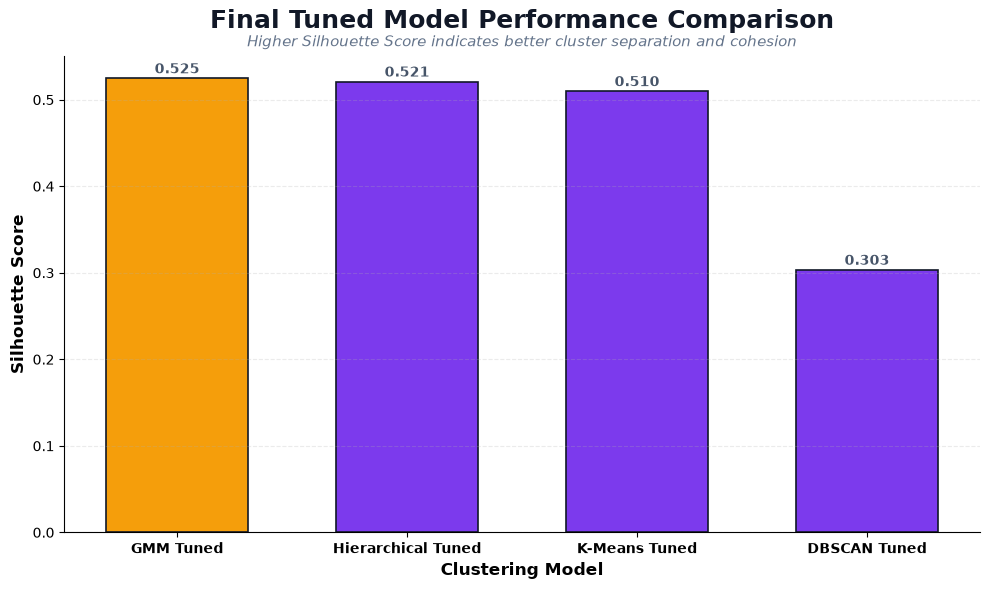

In [241]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

colors = ['#F59E0B'] + ['#7C3AED'] * (len(comparison_tuned_df) - 1)

bars = plt.bar(
    comparison_tuned_df['Model'],
    comparison_tuned_df['Silhouette Score'],
    color=colors,
    edgecolor='#111827',
    linewidth=1.2,
    width=0.62
)

plt.title(
    "Final Tuned Model Performance Comparison",
    fontsize=18,
    fontweight='bold',
    color='#111827',
    pad=20
)

plt.text(
    0.5, 1.02,
    "Higher Silhouette Score indicates better cluster separation and cohesion",
    transform=plt.gca().transAxes,
    ha='center',
    fontsize=11,
    color='#64748B',
    style='italic'
)

plt.xlabel(
    "Clustering Model",
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    "Silhouette Score",
    fontsize=12,
    fontweight='bold'
)

plt.grid(
    axis='y',
    linestyle='--',
    linewidth=0.8,
    alpha=0.25
)

plt.xticks(
    fontsize=10,
    fontweight='bold'
)

plt.yticks(
    fontsize=10
)

ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.006,
        f"{height:.3f}",
        ha='center',
        fontsize=10,
        fontweight='bold',
        color='#475569'
    )

plt.tight_layout()
plt.show()

#### **Final Selected Model Performance**

In [242]:
final_model_selection = pd.DataFrame({
    "Model": ["GMM Tuned"],
    "Silhouette Score": [gmm_tuned_silhouette_score],
    "Calinski-Harabasz Index": [gmm_tuned_calinski],
    "Davies-Bouldin Index": [gmm_tuned_davies]
})

final_model_selection

,Model,Silhouette Score,Calinski-Harabasz Index,Davies-Bouldin Index
0,GMM Tuned,0.52453,4362.054862,0.69164


#####

#### **Final Tuned GMM  Cluster Assignment**

In [243]:
rfm['GMM_Tuned_Cluster'] = gmm_tuned_labels

gmm_tuned_final_distribution = (
    rfm['GMM_Tuned_Cluster']
    .value_counts()
    .sort_index()
)

gmm_tuned_final_distribution

GMM_Tuned_Cluster
0     844
1    3494
Name: count, dtype: int64

#### **Final Tuned GMM Cluster Profile**

In [244]:
gmm_tuned_final_profile = rfm.groupby(
    'GMM_Tuned_Cluster'
).agg(
    Customer_Count=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).reset_index()

gmm_tuned_final_profile

,GMM_Tuned_Cluster,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary
0,0,844,22.957346,8.620853,3104.550640
1,1,3494,107.991700,2.246422,689.047823


#### **Final Tuned GMM Customer Segment Profile**

In [245]:
gmm_tuned_final_profile['Segment'] = gmm_tuned_final_profile[
    'GMM_Tuned_Cluster'
].map({
    0: 'High-Value / Loyal Customers',
    1: 'Low-Value / At-Risk Customers'
})

gmm_tuned_final_profile = gmm_tuned_final_profile[
    [
        'GMM_Tuned_Cluster',
        'Segment',
        'Customer_Count',
        'Avg_Recency',
        'Avg_Frequency',
        'Avg_Monetary'
    ]
]

gmm_tuned_final_profile

,GMM_Tuned_Cluster,Segment,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary
0,0,High-Value / Loyal Customers,844,22.957346,8.620853,3104.550640
1,1,Low-Value / At-Risk Customers,3494,107.991700,2.246422,689.047823


#### **Final Tuned GMM  Customer Segment Distribution (%)**

In [246]:
gmm_tuned_segment_distribution = gmm_tuned_final_profile[
    ['Segment', 'Customer_Count']].copy()

gmm_tuned_segment_distribution['Percentage'] = (
    gmm_tuned_segment_distribution['Customer_Count']
    / gmm_tuned_segment_distribution['Customer_Count'].sum()
) * 100

gmm_tuned_segment_distribution['Percentage'] = (
    gmm_tuned_segment_distribution['Percentage'].round(2)
)

gmm_tuned_segment_distribution

,Segment,Customer_Count,Percentage
0,High-Value / Loyal Customers,844,19.46
1,Low-Value / At-Risk Customers,3494,80.54


#### **Final Tuned GMM  Customer Segment Distribution Visualization**

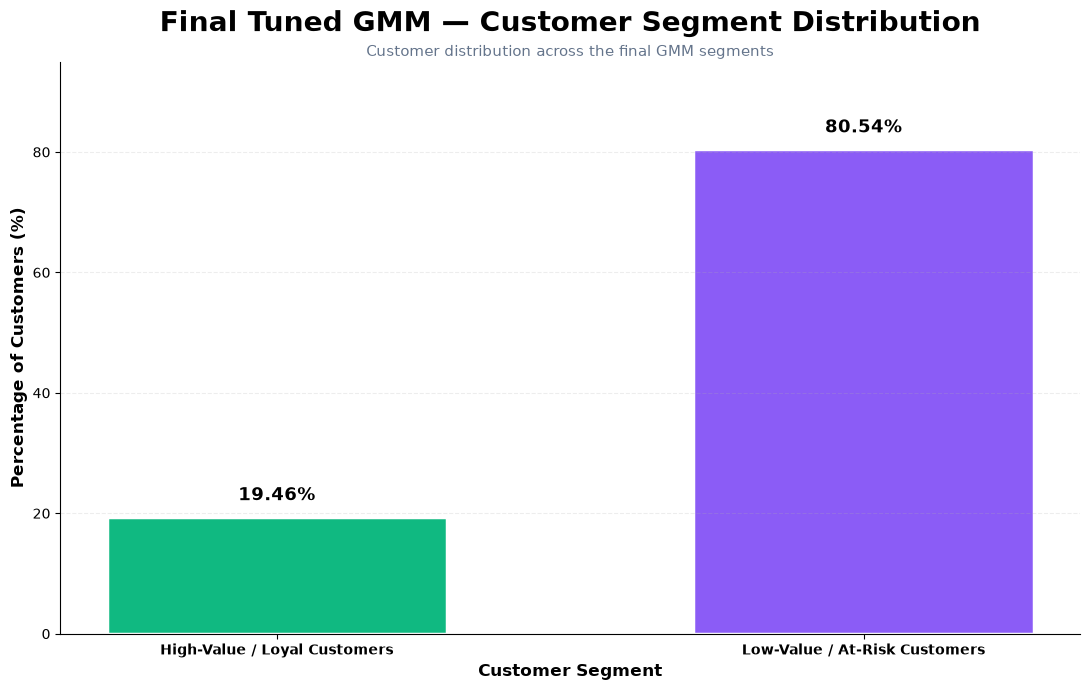

In [247]:
import matplotlib.pyplot as plt
import numpy as np

segments = gmm_tuned_segment_distribution['Segment']
percentages = gmm_tuned_segment_distribution['Percentage']

x = np.arange(len(segments))

plt.figure(figsize=(11, 7))

colors = ['#10B981', '#8B5CF6']

bars = plt.bar(
    x,
    percentages,
    width=0.58,
    color=colors,
    edgecolor='white',
    linewidth=2.5
)

plt.title(
    'Final Tuned GMM — Customer Segment Distribution',
    fontsize=20,
    fontweight='bold',
    pad=22
)

plt.xlabel(
    'Customer Segment',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Percentage of Customers (%)',
    fontsize=12,
    fontweight='bold'
)

plt.xticks(
    x,
    segments,
    fontsize=10,
    fontweight='bold'
)

plt.yticks(fontsize=10)

plt.ylim(0, 95)

plt.grid(
    axis='y',
    linestyle='--',
    linewidth=0.8,
    alpha=0.22
)

ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Value labels
for bar, value in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f'{value:.2f}%',
        ha='center',
        va='bottom',
        fontsize=13,
        fontweight='bold'
    )

# Subtitle
plt.text(
    0.5,
    1.01,
    'Customer distribution across the final GMM segments',
    transform=ax.transAxes,
    ha='center',
    fontsize=11,
    color='#64748B'
)

plt.tight_layout()
plt.show()

######

#### **Final GMM Tuned  PCA Visualization**

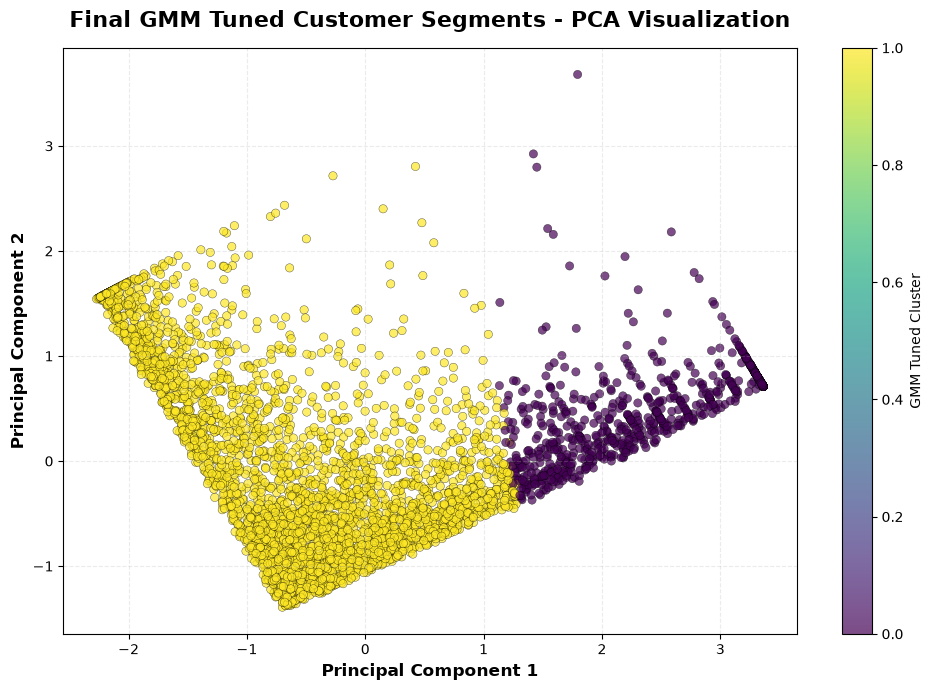

In [248]:
from sklearn.decomposition import PCA

# Final GMM Tuned - PCA Visualization

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=gmm_tuned_labels,
    cmap='viridis',
    alpha=0.7,
    edgecolors='black',
    linewidth=0.3
)

plt.xlabel('Principal Component 1', fontsize=12, fontweight='bold')
plt.ylabel('Principal Component 2', fontsize=12, fontweight='bold')

plt.title(
    'Final GMM Tuned Customer Segments - PCA Visualization',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.colorbar(
    scatter,
    label='GMM Tuned Cluster'
)

plt.grid(
    linestyle='--',
    alpha=0.25
)

plt.tight_layout()
plt.show()

######

# Business Recommendations

## 1. High-Value / Loyal Customers (19.46%)

These customers have low recency, high purchase frequency, and high monetary value. They represent the most valuable customer segment.

### Recommended Actions

* Introduce loyalty and VIP reward programs.
* Provide personalized offers based on purchase history.
* Use cross-selling and upselling strategies.
* Offer early access to new products and exclusive deals.
* Focus on maintaining long-term customer relationships.

## 2. Low-Value / At-Risk Customers (80.54%)

These customers have higher recency, low purchase frequency, and low monetary value, indicating reduced engagement and a higher risk of losing them.

### Recommended Actions

* Launch targeted re-engagement and win-back campaigns.
* Provide personalized discounts and limited-time offers.
* Recommend products based on previous purchases.
* Send reminders and promotional communication to encourage repeat purchases.
* Identify highly inactive customers and prioritize them for retention campaigns.

## Overall Recommendation

The business should focus on retaining **High-Value / Loyal Customers** while implementing targeted re-engagement strategies for the much larger **Low-Value / At-Risk Customer** segment. These strategies can help improve customer retention, increase purchase frequency, and potentially increase overall customer lifetime value.


#####

## **Conclusion**

In this project, RFM (Recency, Frequency, and Monetary) analysis was used to segment customers based on their purchasing behavior.

Four clustering algorithms — **K-Means, Hierarchical Clustering, DBSCAN, and Gaussian Mixture Model (GMM)** — were evaluated using Silhouette Score, Calinski-Harabasz Index, and Davies-Bouldin Index. After hyperparameter tuning, **GMM Tuned** was selected as the final model based on its overall clustering performance.

The final GMM model identified two distinct customer segments:

* **High-Value / Loyal Customers:** 19.46% of customers, characterized by recent purchases, high purchase frequency, and high monetary value.
* **Low-Value / At-Risk Customers:** 80.54% of customers, characterized by less recent purchases, low purchase frequency, and lower monetary value.

These segments provide actionable insights for targeted marketing, customer retention, loyalty programs, and re-engagement strategies. The analysis demonstrates how RFM-based clustering can support data-driven customer segmentation and help businesses develop more effective customer management strategies.


#####

### **Save Final Tuned GMM Model**

In [249]:
import joblib

joblib.dump(gmm_tuned, 'gmm_tuned_model.pkl')

['gmm_tuned_model.pkl']

### **Save StandardScaler**

In [250]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

### **Save RFM Feature Names**

In [251]:
rfm_features = ['Recency', 'Frequency', 'Monetary']

joblib.dump(rfm_features, 'rfm_features.pkl')

['rfm_features.pkl']

#### **Save Cluster-to-Segment Mapping**

In [252]:
cluster_segment_mapping = {
    0: 'High-Value / Loyal Customers',
    1: 'Low-Value / At-Risk Customers'
}

joblib.dump(cluster_segment_mapping, 'cluster_segment_mapping.pkl')

['cluster_segment_mapping.pkl']

### **Save Final GMM Cluster Profile**

In [253]:
joblib.dump(gmm_tuned_final_profile, "gmm_tuned_final_profile.pkl")

['gmm_tuned_final_profile.pkl']